## Compas Analysis 

### Assign 1

#### Step 1. Loading data 


In this step, we load the COMPAS dataset from an online source using pandas.  
This dataset contains criminal defendant information and is commonly used for fairness analysis in machine learning.

We first import the necessary library, then read the dataset from a URL into a pandas DataFrame.  
Finally, we check the shape of the dataset to understand how many observations (rows) and variables (columns) are included.

In [4]:
import pandas as pd # Import pandas library for data manipulation and analysis
# Define the URL where the dataset is stored
# This dataset is from github/ProPublica 
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
# Read the CSV file from the URL into a pandas DataFrame
# The DataFrame 'raw_data' will store all the original data
raw_data = pd.read_csv(url)
# Print the shape of the dataset (rows, columns)
# This helps us understand the size of the dataset
print(raw_data.shape)

(7214, 53)


Observing the result above, we can know that this data has 7214 raws with 53 columns.

#### Step 2 Data Preview


In this step, we display the first 10 rows of the dataset using `df.head(10)` to gain an initial understanding of the data.

This allows us to:
- Inspect the structure and layout of the dataset
- Identify the available variables and their meanings (e.g., age, race, priors_count)
- Check whether the data has been loaded correctly
- Get a sense of the data types (categorical vs numerical)

Previewing the data is an important first step in any data analysis workflow, as it helps us understand what kind of preprocessing and feature engineering may be needed in the following steps.

In [5]:
# Show the first 10 rows of the dataset
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


#### Step 3 Data Preprocessing and Feature Engineering



In this step, we clean and preprocess the dataset to prepare it for analysis and modeling.

First, we select only the relevant variables from the raw dataset to focus on meaningful features.  
Then, we apply several filtering conditions to remove invalid or irrelevant observations, such as missing values,and undefined categories.

Next, we convert variables into appropriate data types.

Finally, we create new derived variables (feature engineering), including categorical factors with specified reference levels. These transformations are important for statistical modeling, especially when interpreting regression coefficients.

Overall, this step ensures that the dataset is clean, consistent, and suitable for further analysis.

In [22]:
import pandas as pd
# Define groups of variables for later type conversion
# numeric_vars: variables that should remain numeric
# datetime_vars: variables that represent timestamps
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select only relevant columns from the raw dataset
# This helps reduce noise and focus on variables used in analysis
df = raw_data[
    [
        "age",
        "c_charge_degree",
        "race",
        "age_cat",
        "score_text",
        "sex",
        "priors_count",
        "days_b_screening_arrest",
        "decile_score",
        "is_recid",
        "two_year_recid",
        "c_jail_in",
        "c_jail_out",
    ]
].copy()

# -------------------------------
# Data Filtering 
# -------------------------------


# Keep only observations where screening arrest happens within [-30, 30] days
df = df[
    df["days_b_screening_arrest"].between(-30, 30)
]
# Remove rows with invalid recidivism values (-1 means missing/undefined)
df = df[df["is_recid"] != -1]
# Remove observations with charge degree "O" (unclassified/other)
df = df[df["c_charge_degree"] != "O"]
# Remove rows with missing COMPAS score
df = df[df["score_text"] != "N/A"]

# -------------------------------
# Type Conversion
# -------------------------------


# Convert datetime columns into proper datetime format
# errors="coerce" will turn invalid parsing into NaT (missing datetime)
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")

# Convert all non-numeric and non-datetime columns into categorical variables
# This is important for modeling and memory efficiency
categorical_cols = [col for col in df.columns if col not in numeric_vars + datetime_vars]
for col in categorical_cols:
    df[col] = df[col].astype("category")

# -------------------------------
# Feature Engineering
# -------------------------------

# Create a categorical version of charge degree
df["crime_factor"] = df["c_charge_degree"].astype("category")

# Create age categories with a defined reference group ("25 - 45")
# The first category will act as baseline in modeling
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Less than 25", "Greater than 45"],
    ordered=False
)
# Define race categories with "Caucasian" as the reference group (first position)
# We dynamically extract all unique race values from the dataset (excluding NaN),
# and then prepend "Caucasian" to ensure it is used as the baseline in modeling.

# This approach is more flexible than hardcoding all categories, because:
# - It automatically adapts to the dataset if new or unexpected race values appear
# - It avoids accidentally omitting valid categories

# If categories are manually hardcoded and do not include all possible values,
# any unmatched values will be converted to NaN when creating the categorical variable.
# This may silently lead to data loss or biased results if not handled properly.

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [x for x in df["race"].dropna().unique() if x != "Caucasian"],
    ordered=False
)
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [x for x in df["race"].dropna().unique() if x != "Caucasian"],
    ordered=False
)

# gender_factor: match Female / Male labels, with Male as reference
# assuming original sex values are Female and Male
df["gender_factor"] = pd.Categorical(
    df["sex"].replace({"Female": "Female", "Male": "Male"}),
    categories=["Male", "Female"],
    ordered=False
)

# Create binary score variable:
# Low -> LowScore
# Medium/High -> HighScore
df["score_factor"] = pd.Categorical
df["score_factor"] = pd.Categorical(
    # We use .ne("Low") to create a boolean mask where "Low" becomes False and others become True
    df["score_text"].ne("Low").map({False: "LowScore", True: "HighScore"}),
    categories=["LowScore", "HighScore"],
    ordered=False
)

# Number of rows
print(len(df))


6172



After applying the filtering conditions, the number of observations is reduced to 6,172 from the original dataset.

This reduction indicates that a portion of the data has been removed due to:
- Missing or undefined values (e.g., is_recid = -1, score_text = "N/A")
- Irrelevant or out-of-scope observations (e.g., c_charge_degree = "O")
- Observations outside the specified screening window (±30 days)

These filtering steps are necessary to ensure data quality and consistency. 

#### Step 4 Filtered Data Preview

After applying the filtering and preprocessing steps, we display the first few rows of the cleaned dataset using df.head().This step serves as a quick check before proceeding to further analysit.

In [7]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n


We use `df.info()` to quickly check the structure of the dataset.  
From the output, we can see that the data types have been correctly converted (e.g., categorical and datetime), and there are no missing values in the selected variables. This confirms that the dataset is clean and ready for further analysis.

### Assign 2


#### Step 5 Data Preparation and Split 


In this step, I define the feature set X and the target variable y, and then split the dataset into training and testing sets.

The target variable is set as 'two_year_recid', which indicates whether an individual reoffends within two years. I chose this variable because it directly reflects the real-world decision context of recidivism risk prediction, which is also where fairness concerns are most important.

For the feature set, I include a mix of behavioral variables (such as prior offenses and charge degree) and demographic variables (such as age, sex, and race). I decided to keep race in the dataset, not because it should be used for prediction, but because it allows me to later evaluate whether the model behaves differently across racial groups. In other words, it is mainly used for fairness auditing rather than improving accuracy.

After defining X and y, I split the data into training and testing sets using an 80/20 split. I also use stratification based on the target variable to make sure the class distribution (recidivism vs. non-recidivism) is preserved in both sets. This helps ensure that the evaluation results are more reliable and not biased due to uneven class distribution.

Overall, this step sets up the foundation for both model training and later analysis of fairness and interpretability.

In [9]:

from sklearn.model_selection import train_test_split

# X and y from the cleaned COMPAS cohort (Lecture 01)
# Define target and features
target = "two_year_recid"

features = [
    "age",
    "age_cat",
    "sex",
    "race",
    "priors_count",
    "c_charge_degree"
]
X = df[features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) # Stratify to maintain class balance in train/test splits
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 6), Test: (1235, 6)


##### Feature Selection Rationale

1. priors_count
This variable measures the number of prior offenses and is one of the most relevant behavioral predictors of recidivism. It is directly related to past behavior and is likely to be a strong and justifiable signal in the model.

2. c_charge_degree
This indicates the severity of the current charge (e.g., felony vs misdemeanor). It captures the seriousness of the offense and provides additional context about the case, which may influence the likelihood of reoffending.

3. age
This variable represents the defendant’s age. Age is commonly used in risk prediction and is likely to have a meaningful relationship with recidivism. However, it is also partially immutable, so while it can improve prediction, it raises some fairness concerns.

4. age_cat
This is a categorical version of age (e.g., young, middle-aged, older). Including both age and age_cat may seem redundant, but I kept it because some models (especially tree-based models) may capture non-linear effects more easily with categorical groupings. It also makes interpretation more intuitive in some cases.

5. sex
Sex is included as a demographic variable that may influence outcomes in real-world datasets. However, it is an immutable attribute and should not be used for actionable recourse. I include it mainly to reflect realistic modeling scenarios and to observe whether the model treats groups differently.

6. race
I deliberately include race not to improve prediction accuracy, but to enable fairness auditing. By keeping this variable, I can evaluate whether the model behaves differently across racial groups (e.g., differences in FPR or FNR). At the same time, I recognize that race is a sensitive and immutable attribute, and its presence may introduce or reveal bias.


#### Step 6 Data representation alignment


In this step, I apply different transformations to numerical and categorical features using a ColumnTransformer.

Numerical features are standardized using StandardScaler to ensure they are on a comparable scale. This is important because many models (especially linear models) are sensitive to the magnitude of input features.

Categorical features are transformed using one-hot encoding, which converts each category into a binary indicator. This allows the model to process categorical variables such as race and sex in a numerical format.

By combining these transformations in a single preprocessing pipeline, I ensure that all features are consistently transformed before being passed into the model. This also helps maintain reproducibility and prevents data leakage, since the same transformations are applied to both training and test data.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = [
    "age",
    "priors_count"
]

category_features = [
    "age_cat",
    "sex",
    "race",
    "c_charge_degree"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(
        handle_unknown="ignore"), category_features),
])


lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### Logistic regression (GLM -- interpretable by design)

In [14]:

# Logistic regression (GLM -- interpretable by design)
model = lr_pipeline.named_steps["classifier"]

feature_names = (
    numeric_features +
    list(lr_pipeline.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .get_feature_names_out(category_features))
)

coef = model.coef_[0]

for name, c in zip(feature_names, coef):
    print(f"{name:30} {c:.4f}")


age                            -0.6298
priors_count                   0.7808
age_cat_25 - 45                -0.2753
age_cat_Greater than 45        0.2089
age_cat_Less than 25           -0.0822
sex_Female                     -0.2608
sex_Male                       0.1122
race_African-American          0.1748
race_Asian                     -0.3095
race_Caucasian                 0.1324
race_Hispanic                  -0.1593
race_Native American           -0.0230
race_Other                     0.0360
c_charge_degree_F              0.0712
c_charge_degree_M              -0.2198


##### **Interpretation of Logistic Regression Coefficients and GLM Limitations**


In this model, we are using logistic regression, which is a type of GLM. The model does **not directly predict probability**, but instead models the **log-odds (logit)** of recidivism. So all the coefficients we see are actually affecting the log-odds, not the probability itself.

From the results, `priors_count` has a strong positive coefficient (0.7808), meaning more prior offenses are associated with higher predicted risk. For `age`, the coefficient is negative (-0.6298), suggesting that as age increases, the predicted risk decreases.

However, something interesting appears when we also include `age_cat`. For example, `age_cat_Greater than 45` has a positive coefficient, while `age_cat_Less than 25` is negative. This seems a bit inconsistent with the continuous `age` variable. My understanding is that once we include both a continuous variable (`age`) and its grouped version (`age_cat`), the model is trying to split the effect across multiple representations, which can make interpretation less straightforward and sometimes even contradictory.

For categorical variables, such as race and sex, we see that some groups (e.g., `race_African-American`, `sex_Male`) have positive coefficients. This suggests that these features are influencing the model’s predictions, which raises concerns since these are sensitive attributes and could relate to fairness issues.


 ##### **Limitations of GLM (Logistic Regression)**

- **Linearity assumption**:  
  The model assumes a linear relationship between features and log-odds. This means the effect of a feature is constant everywhere, which may not match real-world patterns.

- **Additivity (no interactions)**:  
  Features are added together independently. The model does not capture interactions unless we manually include them.

- **Mixed representations can be confusing**:  
  Including both continuous (`age`) and categorical (`age_cat`) versions of the same feature can lead to overlapping or hard-to-interpret effects.

- **Correlation between features**:  
  If features are correlated (e.g., race and other variables), the coefficients may be unstable or misleading.

- **Not causal**:  
  Coefficients only show associations, not cause-and-effect relationships.

- **Sensitive attributes risk**:  
  Even if the model is interpretable, it can still rely on sensitive features (like race), which may lead to unfair outcomes.o we shouldn’t interpret them as “this feature causes higher risk,” but rather that it is correlated with the model’s prediction.

#### Gradient-boosted tree (black-box)


In this step, I train a Gradient Boosting Classifier as a more complex, black-box model. Compared to logistic regression, this model can capture non-linear relationships and interactions between features, which may improve predictive performance.

I use the same preprocessing pipeline (scaling numeric features and one-hot encoding categorical features) to ensure consistency between models.

The purpose of including this model is to later apply post-hoc explanation methods (such as LIME and SHAP) and compare how explanations differ between interpretable (GLM) and non-interpretable (black-box) models.


In [15]:
# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42))
])

gbt_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


This function evaluates model performance across different groups (in this case, race) to assess potential bias or fairness issues.

First, it generates predictions (`pred`) and predicted probabilities (`pred_prob`) for each instance. Then, it groups the data by the specified attribute (race) and computes performance metrics within each group.

The metrics include:
- Accuracy (overall correctness)
- FPR (False Positive Rate): how often non-recidivists are incorrectly classified as high risk
- FNR (False Negative Rate): how often recidivists are missed
- AUC: overall classification performance

The goal is to check whether the model behaves differently across racial groups. If metrics such as FPR or FNR differ significantly, this may indicate potential bias in the model.
import pandas as pd

In [16]:
from sklearn.metrics import (confusion_matrix,
                             accuracy_score,
                             roc_auc_score)

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"],
            labels=[0, 1]
        ).ravel()
        results.append({
            "race" : group,
            "n" : len(gdf),
            "accuracy" : round(accuracy_score(
                gdf["actual"], gdf["pred"]), 3),
            "FPR" : round(fp / (fp + tn), 3),
            "FNR" : round(fn / (fn + tp), 3),
            "AUC" : round(roc_auc_score(
                gdf["actual"],
                gdf["pred_prob"]), 3),
        })
    return pd.DataFrame(results).sort_values("n", ascending=False)


**Compare Model Performance by Race**

In this step, I apply the group-level evaluation function to both the logistic regression model and the gradient boosting model using the test dataset.

This allows me to compare how each model performs across different racial groups and identify any disparities in prediction outcomes.

By comparing an interpretable model (logistic regression) with a black-box model (gradient boosting), I can also observe whether increased model complexity leads to differences in fairness, not just accuracy.

This step is important for understanding whether the model may disproportionately impact certain groups, which is a key concern in responsible machine learning.



In [17]:
print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.705  0.306  0.285  0.754
2         Caucasian  427     0.656  0.169  0.634  0.665
3          Hispanic   94     0.617  0.102  0.689  0.617
5             Other   65     0.785  0.085  0.556  0.728
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000    NaN    NaN

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.685  0.342  0.291  0.741
2         Caucasian  427     0.679  0.162  0.584  0.680
3          Hispanic   94     0.681  0.143  0.511  0.642
5             Other   65     0.738  0.128  0.611  0.726
1             Asian    7     0.714  0.167  1.000  0.667
4   Native American    1     1.000  0.000    NaN    NaN


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_47075/3675387357.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, gdf in X_.groupby(group_col):
/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_47075/3675387357.py:23: RuntimeWarning: invalid value encountered in scalar divide
  "FNR" : round(fn / (fn + tp), 3),
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_47075/3675387357.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tr

**Fairness Analysis by Race**

From the results, the model shows clear differences in performance across racial groups. In particular, the False Positive Rate (FPR) is much higher for African-American individuals (0.306 in logistic regression and 0.342 in gradient boosting), meaning they are more likely to be incorrectly classified as high risk. 

On the other hand, the False Negative Rate (FNR) is significantly higher for Caucasian and Hispanic groups (e.g., 0.634 and 0.689 in logistic regression), indicating that the model is more likely to underestimate their risk.

This suggests that the model is not making errors uniformly. Instead, it appears to be stricter for some groups and more lenient for others, which raises concerns about fairness and potential bias.

Additionally, results for smaller groups (such as Asian and Native American) are unstable due to very limited sample sizes, making those metrics less reliable.

Overall, these findings indicate that the model may disproportionately impact different groups, and further investigation into potential sources of bias (such as proxy variables or data imbalance) is necessary.

#### Qestion 1: 
#### Compute SHAP values for your model on the test set. Produce: (a) a beeswarm summary plot, (b) a waterfall plot for the highest-risk and lowest-risk defendant in each racial group.

##### **(a)beeswarm summary plot**

In [ ]:
import shap
X_test_enc = preprocessor.transform(X_test)

if hasattr(X_test_enc, "toarray"):
    X_test_enc = X_test_enc.toarray()

feat_names = (
    numeric_features +
    list(preprocessor
         .named_transformers_["cat"]
         .get_feature_names_out(category_features))
)

X_test_enc_df = pd.DataFrame(X_test_enc, columns=feat_names, index=X_test.index)

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc_df, max_samples=100)
)

shap_values = explainer_shap(X_test_enc_df, check_additivity=False)

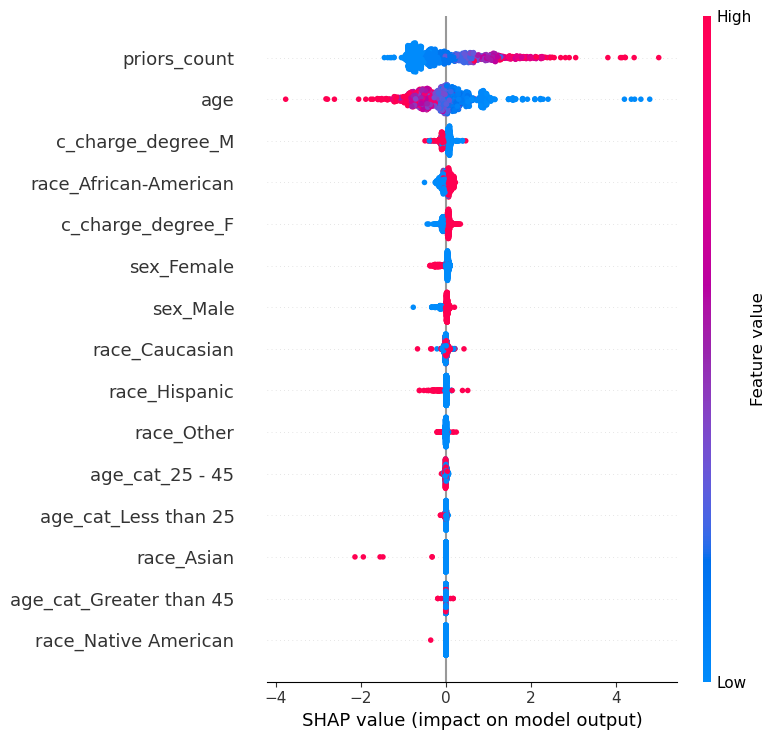

In [ ]:
# Global beeswarm
shap.summary_plot(shap_values, X_test_enc,
                  feature_names=feat_names)

The SHAP beeswarm plot provides a global view of how different features influence the model’s predictions.

From the plot, the most important feature is `priors_count`, where higher values strongly push predictions toward higher recidivism risk. This suggests that the model heavily relies on prior offenses when making decisions.

Age is the second most important feature. Younger individuals tend to have positive SHAP values (increasing predicted risk), while older individuals tend to have negative SHAP values (decreasing risk). This indicates that the model associates younger age with higher likelihood of reoffending.

Charge degree and sex also have noticeable effects, although their influence is less consistent compared to priors_count. For example, male defendants tend to have slightly higher predicted risk than female defendants.

Importantly, the presence of race-related features among the influential variables does not imply that certain racial groups are inherently more likely to reoffend. Instead, it indicates that the model is using race (or correlated features) in its decision-making process. 

This raises potential concerns about fairness, as the model may be relying on sensitive attributes directly or indirectly through proxy variables. Therefore, further investigation is needed to determine whether these patterns reflect legitimate predictive signals or unintended bias in the data and model.

Finally, categorical age features (e.g., age_cat) appear to have minimal contribution, suggesting that the continuous age variable already captures most of the relevant information.

Overall, the model appears to rely on both behavioral features (e.g., prior offenses) and demographic features, which highlights the need for further fairness and governance analysis.

##### **(b) a waterfall plot for the highest-risk and lowest-risk defendant in each racial group**

In [ ]:
# Waterfall plots for the highest-risk and lowest-risk defendant in each racial group

X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

selected_cases = []

for race_group, gdf in X_test_copy.groupby("race"):
    gdf_sorted = gdf.sort_values("pred_prob")
    
    lowest_idx = gdf_sorted.index[0]
    highest_idx = gdf_sorted.index[-1]
    
    selected_cases.append((race_group, "Lowest risk", lowest_idx))
    selected_cases.append((race_group, "Highest risk", highest_idx))

/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_2781/348331948.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for race_group, gdf in X_test_copy.groupby("race"):


**Why select the most extreme individuals for SHAP analysis?** 

In this analysis, instead of randomly selecting individuals, we intentionally choose two extreme cases within each racial group: the lowest-risk and the highest-risk defendant based on predicted probability.

The main reason for this approach is that SHAP provides local explanations, meaning it explains the model’s decision for a specific individual rather than the overall model behavior. If I were to select individuals randomly, many of them might have average prediction scores, where feature contributions are relatively small and less informative. This would make it harder to clearly understand how the model is making decisions.

By selecting the most extreme cases, the contribution of key features becomes more pronounced. For high-risk individuals, we can clearly see which features push the prediction upward, while for low-risk individuals, we can observe which features reduce the predicted risk. This contrast makes it easier to interpret the model’s decision boundary and identify the most influential factors.

Additionally, applying this selection strategy within each racial group allows for a more structured comparison across groups. It helps reveal whether similar features drive predictions consistently, or whether different groups are influenced by different factors, which is important for identifying potential fairness or bias issues.

Overall, this approach provides a more informative and interpretable use of SHAP compared to random sampling.

African-American — Lowest risk


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_2781/1637371975.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for race_group, gdf in X_test_copy.groupby("race"):


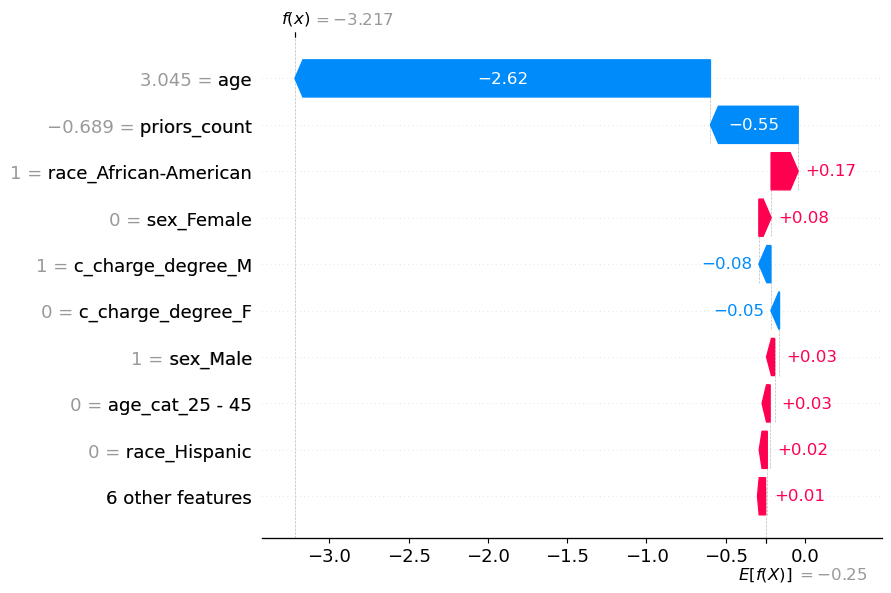

African-American — Highest risk


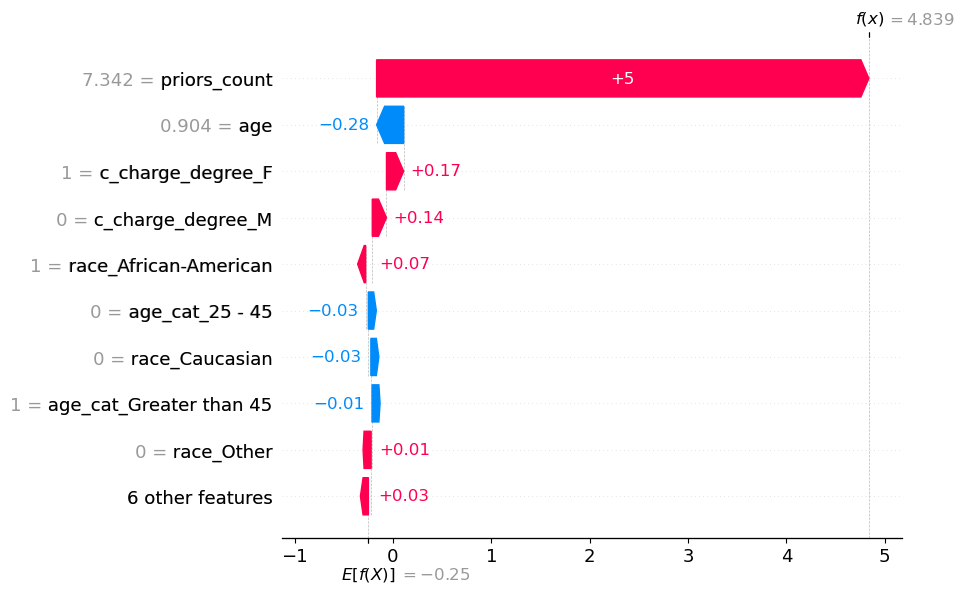

Asian — Lowest risk


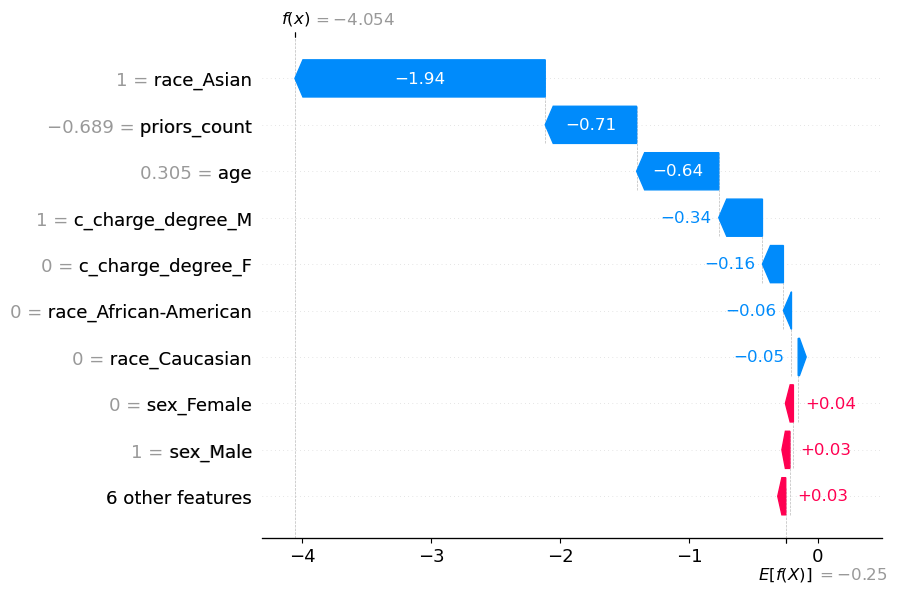

Asian — Highest risk


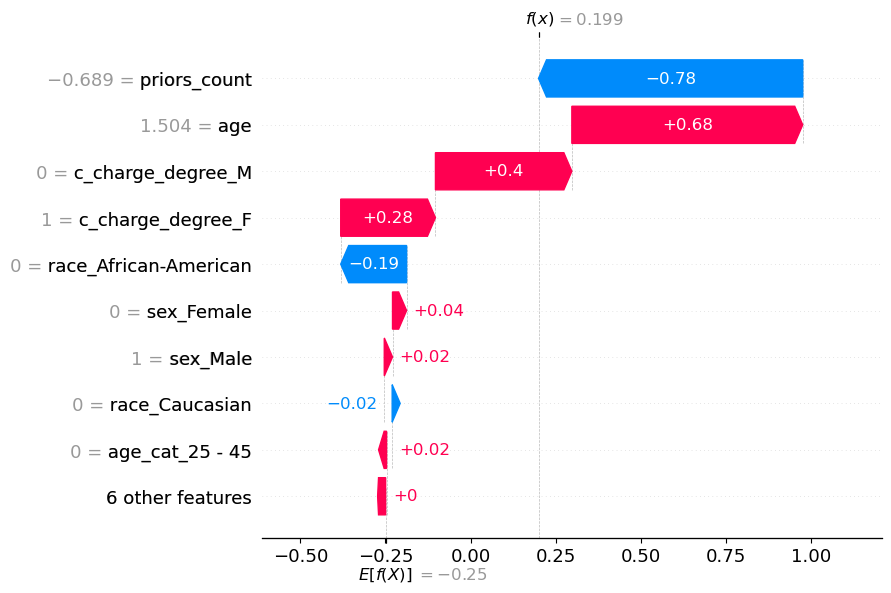

Caucasian — Lowest risk


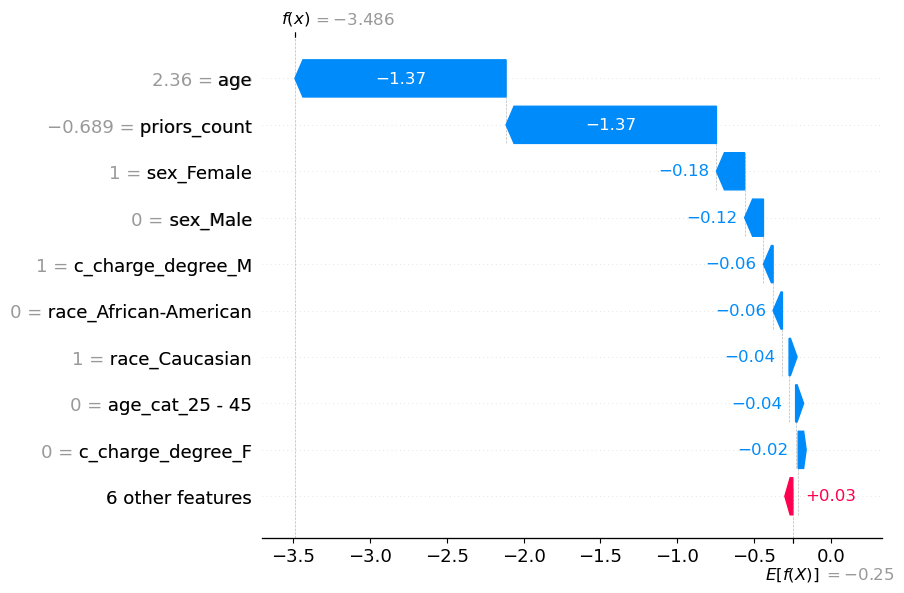

Caucasian — Highest risk


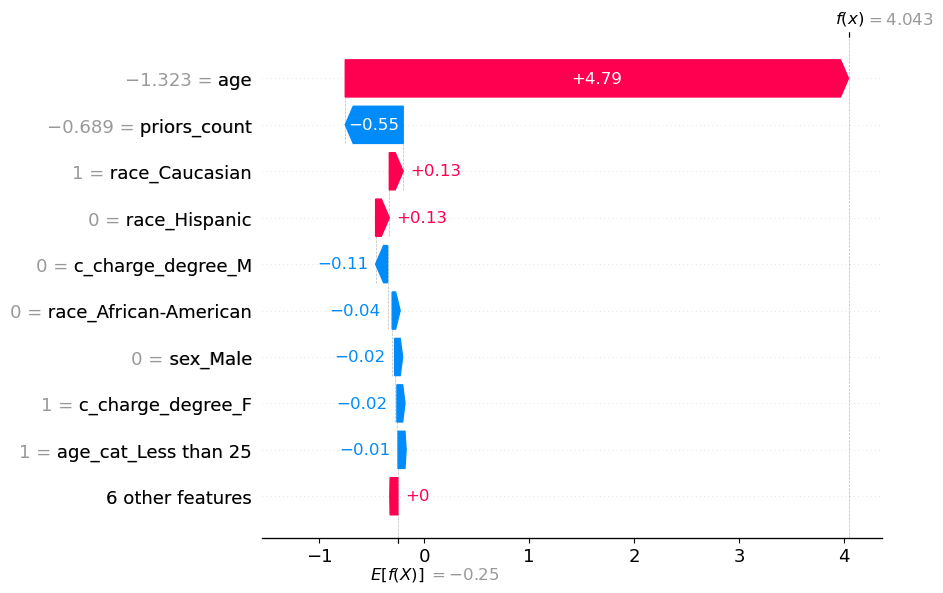

Hispanic — Lowest risk


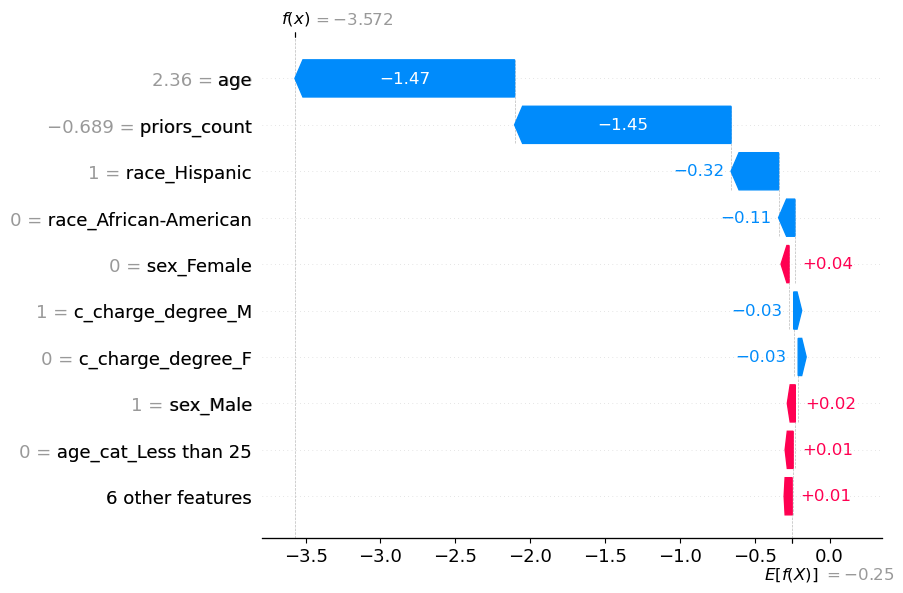

Hispanic — Highest risk


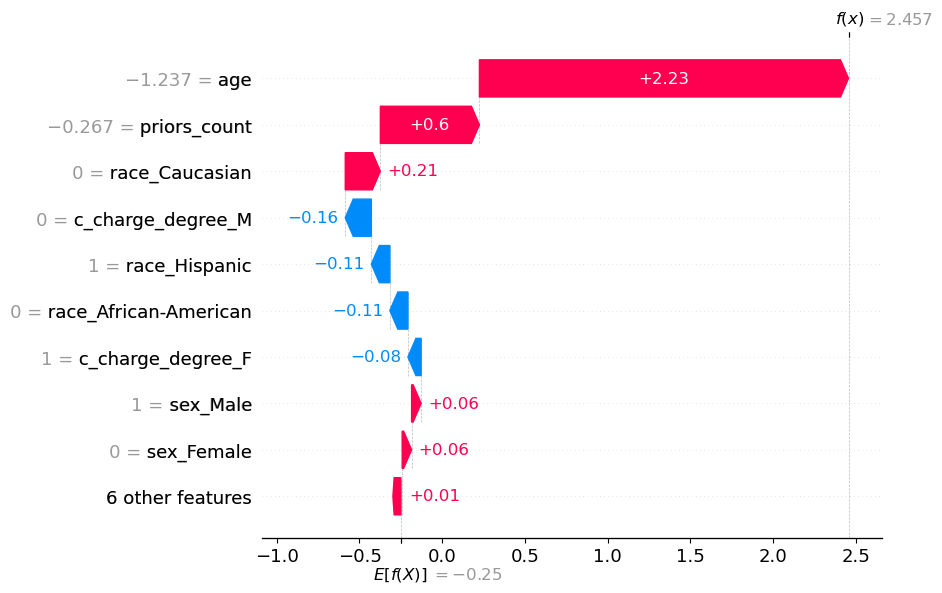

Native American — Lowest risk


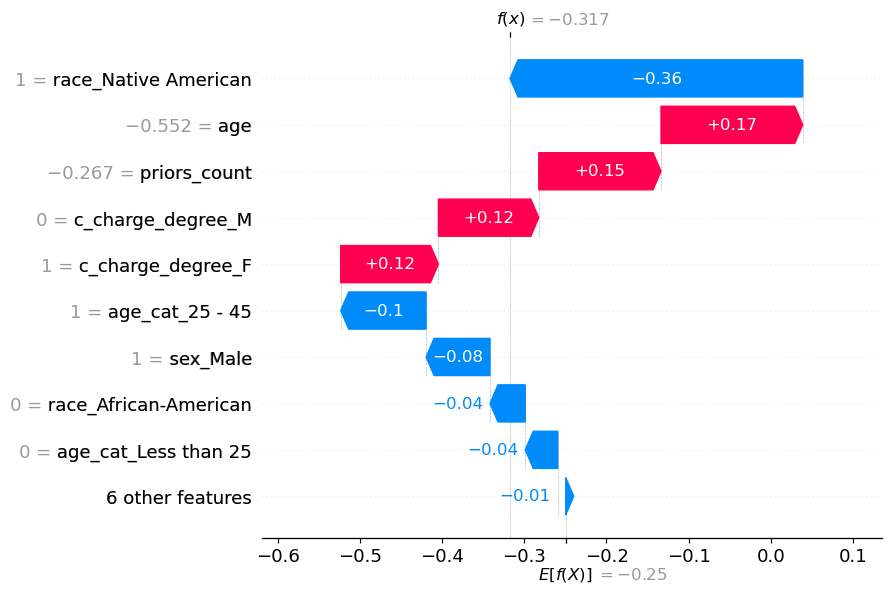

Native American — Highest risk


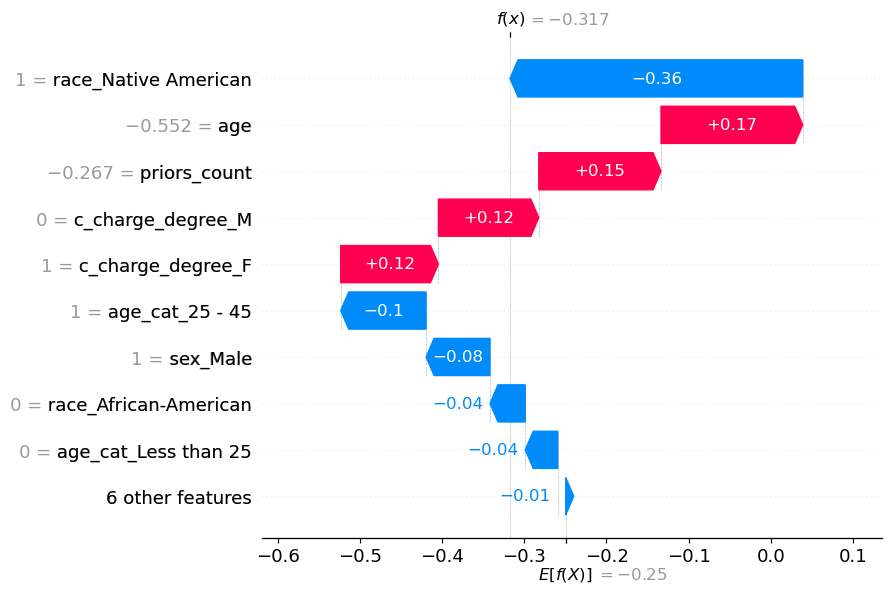

Other — Lowest risk


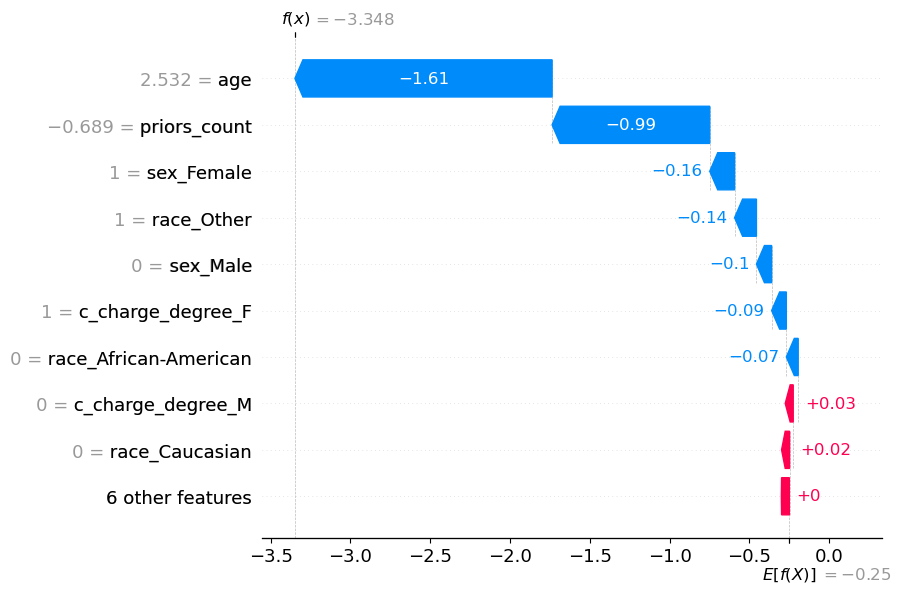

Other — Highest risk


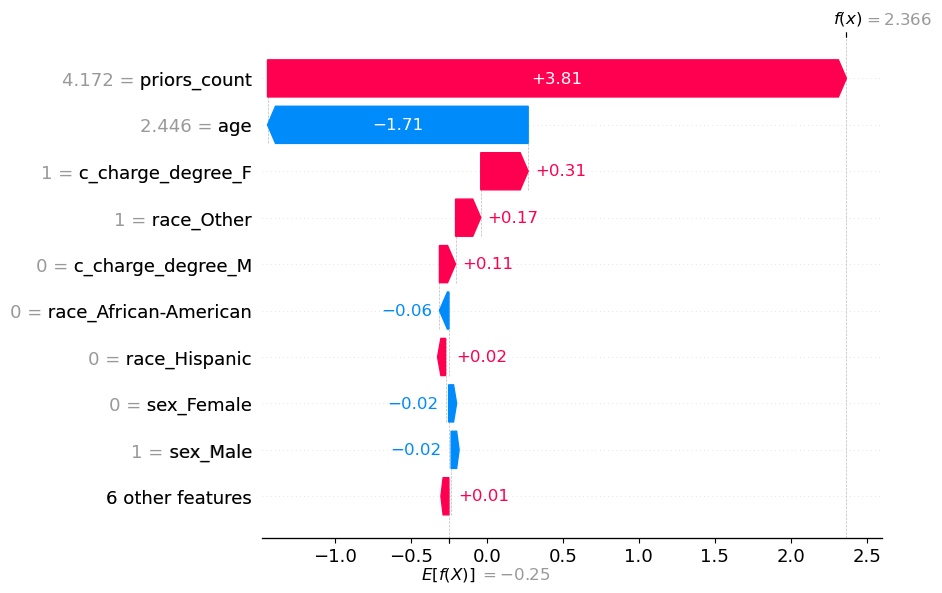

In [ ]:
# Select highest-risk and lowest-risk defendant in each racial group
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

selected_cases = []

for race_group, gdf in X_test_copy.groupby("race"):
    gdf_sorted = gdf.sort_values("pred_prob")

    lowest_idx = gdf_sorted.index[0]
    highest_idx = gdf_sorted.index[-1]

    selected_cases.append((race_group, "Lowest risk", lowest_idx))
    selected_cases.append((race_group, "Highest risk", highest_idx))


# Plot SHAP waterfall for each selected case
for race_group, risk_label, idx in selected_cases:
    loc = X_test.index.get_loc(idx)

    exp = shap.Explanation(
        values=shap_values.values[loc],
        base_values=shap_values.base_values[loc],
        data=X_test_enc_df.iloc[loc].values,
        feature_names=feat_names
    )

    print(f"{race_group} — {risk_label}")
    shap.plots.waterfall(exp, max_display=10)

**Observations from SHAP waterfall plots**

From the SHAP waterfall plots across different racial groups, a consistent pattern can be observed in how the model makes predictions. The most dominant feature driving the prediction is `priors_count`. In almost all high-risk cases, a large number of prior offenses strongly pushes the prediction toward higher risk, often with a much larger contribution compared to other features.

Age is another important factor. Younger individuals tend to increase the predicted risk, while older individuals reduce it. This pattern appears consistently across multiple groups, suggesting that age plays a systematic role in the model’s decision-making.

Race-related features such as `race_African-American`, `race_Caucasian`, or `race_Asian` also appear in the explanations. However, their contributions are generally smaller compared to features like `priors_count`. Even though the magnitude is smaller, the presence of these variables is still noteworthy and raises concerns about whether the model may be relying on sensitive attributes or correlated proxy variables.

Overall, the model seems to rely primarily on behavioral and demographic features (such as prior offenses and age), but sensitive attributes are still present in the decision process.


**Limitations of the analysis**

While SHAP provides useful insights into model behavior, there are several important limitations to consider.

First, SHAP explanations are local, meaning they only explain individual predictions rather than the overall model behavior. The conclusions drawn from a few selected individuals (even extreme ones) may not generalize to the entire dataset.

Second, SHAP does not imply causality. A feature having a large contribution does not mean that changing this feature in reality would change the outcome. It only reflects how the model uses that feature internally.

Third, the analysis depends on how features are represented. For example, one-hot encoded variables (such as race categories) may appear as separate features, which can sometimes exaggerate or fragment their perceived impact.

Fourth, the selection of extreme cases, while useful for interpretability, may introduce bias in interpretation. These cases highlight strong effects but may not reflect typical or average decisions made by the model.

Finally, the presence of race-related features in the explanations raises potential fairness concerns, but SHAP alone cannot determine whether the model is unfair. Additional analysis, such as fairness metrics or proxy detection, is required to make that assessment.


**Key takeaway**

In summary, SHAP helps reveal how the model makes decisions at the individual level, highlighting the importance of features like prior offenses and age. However, these explanations should be interpreted carefully, as they do not capture the full picture of model behavior or fairness. Additional evaluation is necessary to ensure responsible use of the model.

#### Question2: 
#### Run LIME on the same four individuals. Compare LIME and SHAP feature attributions. Where do they agree? Where do they diverge? What does divergence imply for governance?

**Selecting four individuals for SHAP–LIME comparison**

To enable a direct comparison between SHAP and LIME, I select four specific individuals from the test set. These include the highest-risk and lowest-risk defendants within the Hispanic and Caucasian groups.

For each group, I sort individuals based on their predicted probability of recidivism and select the extremes (lowest and highest). This ensures that the selected cases represent very different model behaviors, which makes it easier to analyze how each explanation method attributes feature importance.

By applying both SHAP and LIME to the same four individuals, I can more clearly compare where the two methods agree and where they diverge.

In [ ]:
# Select four individuals for SHAP-LIME comparison:
# Hispanic highest/lowest risk and Caucasian highest/lowest risk

# Initialize an empty list to store the selected individuals
# Each element will be a tuple: (race_group, risk_label, index_in_dataset)
selected_cases_4 = []

# Loop over the two selected racial groups
for race_group in ["Hispanic", "Caucasian"]:

    # Filter the test dataset to only include rows from the current racial group
    # Then sort these individuals by their predicted probability of recidivism
    # (from lowest to highest)
    gdf_sorted = X_test_copy[
        X_test_copy["race"] == race_group
    ].sort_values("pred_prob")

    # Select the individual with the lowest predicted risk (first row after sorting)
    lowest_idx = gdf_sorted.index[0]

    # Select the individual with the highest predicted risk (last row after sorting)
    highest_idx = gdf_sorted.index[-1]

    # Store both individuals as tuples:
    # - race_group: which group the individual belongs to
    # - risk_label: whether this is the lowest-risk or highest-risk case
    # - index: the row identifier in the dataset (used later to retrieve the exact individual)
    selected_cases_4.append((race_group, "Lowest risk", lowest_idx))
    selected_cases_4.append((race_group, "Highest risk", highest_idx))

**SHAP waterfall for the same four individuals**


In this step, I generate SHAP waterfall plots for the four individuals selected earlier (highest-risk and lowest-risk cases within the Hispanic and Caucasian groups).

For each individual, I retrieve the corresponding SHAP values and construct a SHAP Explanation object, which combines the feature values, SHAP contributions, and baseline prediction. This allows the waterfall plot to clearly show how each feature pushes the model prediction higher or lower.

The waterfall plots provide a local explanation for each individual prediction, making it possible to understand which features are driving the model's decision in each case. These results will later be compared with LIME explanations to evaluate where the two methods agree and where they differ.

Hispanic — Lowest risk


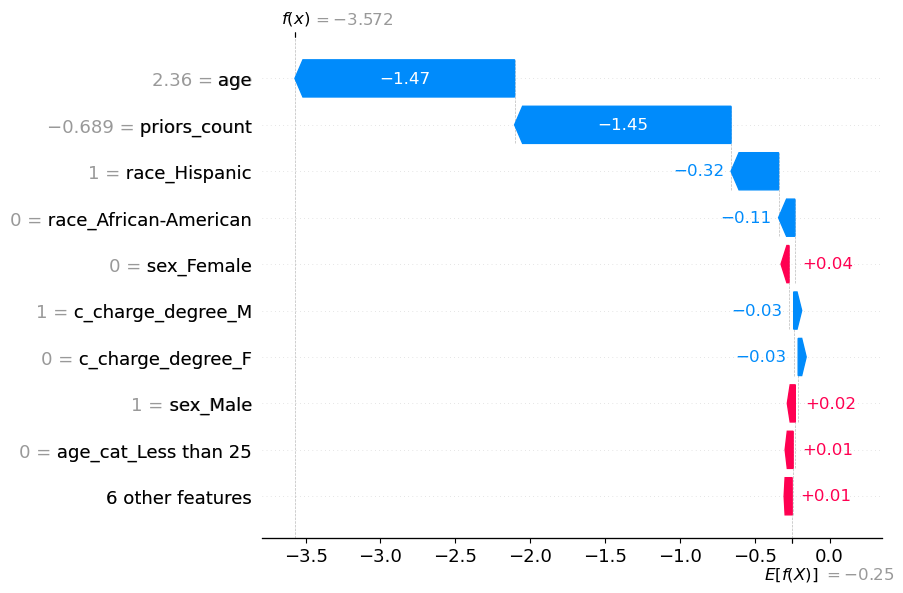

Hispanic — Highest risk


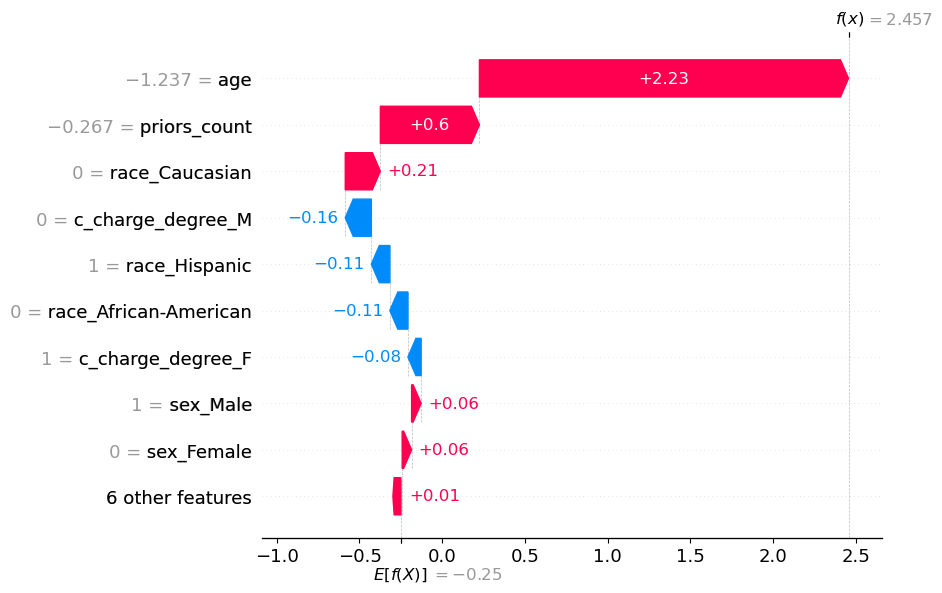

Caucasian — Lowest risk


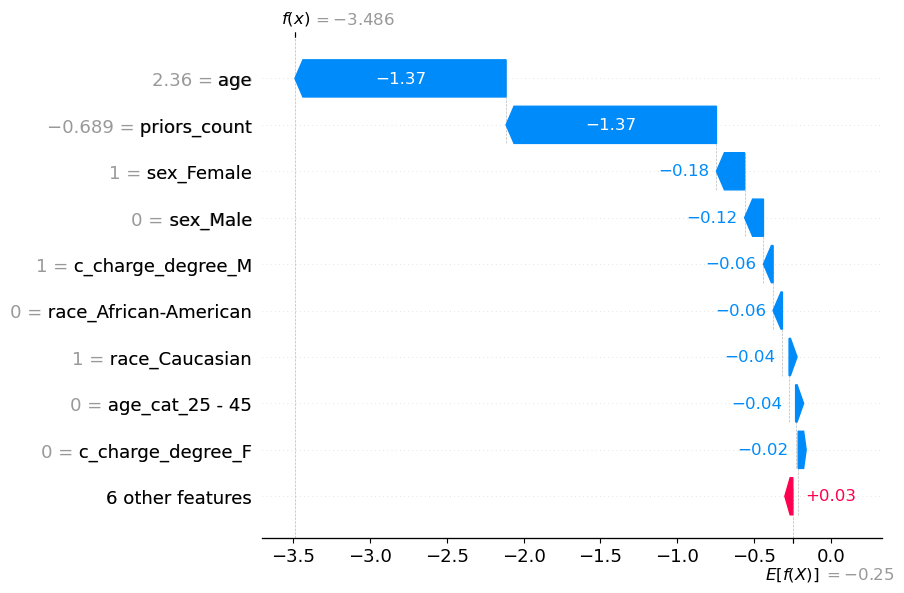

Caucasian — Highest risk


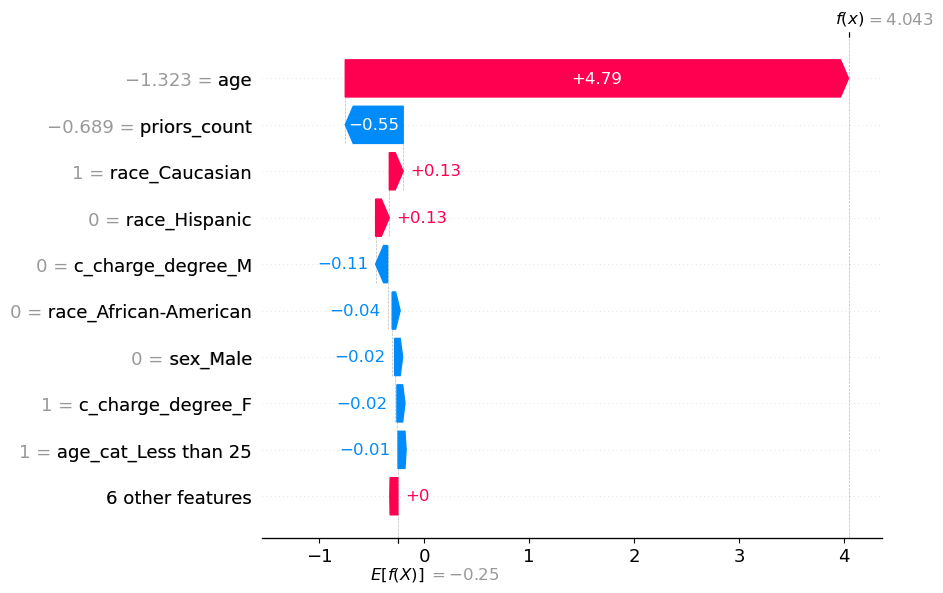

In [ ]:
# Loop through the four selected individuals
# Each tuple contains: (race_group, risk_label, dataset_index)
for race_group, risk_label, idx in selected_cases_4:

    # Convert the original dataset index to positional index
    # This is needed because SHAP values are stored in array format (0-based index)
    loc = X_test.index.get_loc(idx)

    # Construct a SHAP Explanation object for this specific individual
    # This step links SHAP values with actual feature names and values
    exp = shap.Explanation(
        values=shap_values.values[loc],              # SHAP values for this individual
        base_values=shap_values.base_values[loc],    # Model baseline prediction (expected value)
        data=X_test_enc_df.iloc[loc].values,         # Feature values (after encoding)
        feature_names=feat_names                     # Human-readable feature names
    )

    # Print a label to indicate which individual is being explained
    print(f"{race_group} — {risk_label}")

    # Plot the SHAP waterfall chart
    # This shows how each feature contributes to pushing the prediction up or down
    shap.plots.waterfall(exp, max_display=10)

**Extract top SHAP features for easier comparison**


To make the comparison between SHAP and LIME more structured, I extract the most important features for each of the four selected individuals.

For each individual, I create a table that includes feature names, their corresponding values, and their SHAP contributions. I then rank the features by the absolute value of their SHAP scores, which reflects their overall influence on the prediction regardless of direction.

I keep only the top six features for each individual to focus on the most influential factors. This simplifies the comparison with LIME, since LIME also returns a limited number of top features.

By organizing SHAP results into a tabular format, it becomes easier to directly compare feature attributions between SHAP and LIME for the same individuals.

In [ ]:
# Extract top SHAP feature attributions for the same four individuals

# Initialize a list to store top features for each individual
shap_top_results = []

# Loop through the selected four individuals
for race_group, risk_label, idx in selected_cases_4:

    # Convert dataset index to positional index (needed for SHAP arrays)
    loc = X_test.index.get_loc(idx)

    # Create a DataFrame that aligns:
    # - feature names
    # - feature values
    # - SHAP values
    case_df = pd.DataFrame({
        "feature": feat_names,                          # Feature names
        "value": X_test_enc_df.iloc[loc].values,        # Encoded feature values
        "shap_value": shap_values.values[loc]           # SHAP contribution
    })

    # Take absolute value of SHAP to measure importance (magnitude only)
    case_df["abs_shap"] = case_df["shap_value"].abs()

    # Sort features by importance (largest absolute SHAP first)
    # and keep only the top 6 most influential features
    case_top = case_df.sort_values("abs_shap", ascending=False).head(6).copy()

    # Add metadata to identify which individual this belongs to
    case_top["race_group"] = race_group
    case_top["risk_label"] = risk_label

    # Store results
    shap_top_results.append(case_top)

# Combine all individuals into one DataFrame
shap_top_df = pd.concat(shap_top_results, ignore_index=True)

# Display selected columns for easier comparison
shap_top_df[["race_group", "risk_label", "feature", "value", "shap_value"]]

,race_group,risk_label,feature,value,shap_value
0,Hispanic,Lowest risk,age,2.360240,-1.467590
1,Hispanic,Lowest risk,priors_count,-0.689405,-1.446075
2,Hispanic,Lowest risk,race_Hispanic,1.000000,-0.317561
3,Hispanic,Lowest risk,race_African-American,0.000000,-0.109013
4,Hispanic,Lowest risk,sex_Female,0.000000,0.039095
5,Hispanic,Lowest risk,c_charge_degree_M,1.000000,-0.031094
6,Hispanic,Highest risk,age,-1.237085,2.231502
7,Hispanic,Highest risk,priors_count,-0.266677,0.599000
8,Hispanic,Highest risk,race_Caucasian,0.000000,0.212118
9,Hispanic,Highest risk,c_charge_degree_M,0.000000,-0.157795


**LIME waterfall for the same four individuals**


This step is essential because it defines how LIME understands the model and the input data. Since the model is trained on preprocessed features (including scaling and one-hot encoding), it is important to apply the exact same transformation to the training data before passing it to LIME. Without this consistency, the explanations generated by LIME would not correctly reflect the model’s behavior.

The training data provided to LIME serves as a reference distribution. LIME generates local perturbations around each instance based on this data, and then fits a simple interpretable model (e.g., a linear model) to approximate the black-box model locally. Therefore, the quality of LIME explanations heavily depends on how well this training data represents the feature space used by the model.

Additionally, converting the data into a dense format ensures compatibility with LIME, and providing feature names improves the interpretability of the results. The use of discretization for continuous variables further enhances interpretability by expressing feature effects in terms of ranges rather than raw numeric values.

Overall, this step ensures that LIME operates on the correct feature representation and produces meaningful, human-readable explanations that can be reliably compared with SHAP.

In [ ]:
# Import LIME explainer for tabular data
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Apply the same preprocessing (scaling + one-hot encoding) to training data
# This ensures LIME sees the same feature space as the model
X_train_enc = preprocessor.transform(X_train)

# If the result is a sparse matrix, convert it to a dense array
# LIME requires dense input format
if hasattr(X_train_enc, "toarray"):
    X_train_enc = X_train_enc.toarray()

# Initialize the LIME explainer
explainer = LimeTabularExplainer(
    training_data = X_train_enc,      # Encoded training data (used to sample perturbations)
    feature_names = feat_names,       # Feature names after encoding
    class_names = ["No Recid", "Recid"],  # Target class labels
    mode = "classification",          # Specify classification problem
    discretize_continuous = True,     # Convert continuous variables into bins (improves interpretability)
    random_state = 42                 # Ensure reproducibility
)


For each selected individual, the code first applies the same preprocessing steps used during model training, ensuring that LIME receives the same feature representation as the classifier. LIME then generates a local explanation by approximating the black-box model around that specific individual. This helps identify which features are most influential in pushing that individual’s prediction toward higher or lower risk.

Only the top six features are retained for each case so that the results remain interpretable and can be more directly compared with the top SHAP features extracted earlier. 


In [ ]:
# Run LIME on the same four individuals

# Initialize a list to store top LIME features for each individual
lime_top_results = []

# Loop through the same four selected individuals
for race_group, risk_label, idx in selected_cases_4:

    # Apply the same preprocessing to the selected individual
    # The double brackets [[idx]] keep the result as a DataFrame with one row
    row_enc = preprocessor.transform(X_test.loc[[idx]])

    # Convert sparse matrix to dense array if needed
    # LIME expects dense input
    if hasattr(row_enc, "toarray"):
        row_enc = row_enc.toarray()

    # Generate a local LIME explanation for this individual
    # data_row = the encoded feature vector for this person
    # predict_fn = the classifier's probability output
    # num_features = only keep the top 6 most important local features
    exp = explainer.explain_instance(
        data_row = row_enc[0],
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 6
    )

    # Print the case label and predicted probability for reference
    print(f"\nLIME: {race_group} — {risk_label}")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")

    # Print the local feature contributions and store them for later comparison
    for feat, weight in exp.as_list():
        print(f"{feat:<40} {weight:+.4f}")
        lime_top_results.append({
            "race_group": race_group,
            "risk_label": risk_label,
            "feature": feat,
            "lime_weight": weight
        })

# Convert the stored LIME results into a DataFrame for easier comparison with SHAP
lime_top_df = pd.DataFrame(lime_top_results)
display(lime_top_df)


LIME: Hispanic — Lowest risk
Predicted probability: 0.027
race_Asian <= 0.00                       +0.2790
age > 0.56                               -0.2114
0.00 < c_charge_degree_M <= 1.00         -0.0473
c_charge_degree_F <= 0.00                -0.0259
race_Hispanic > 0.00                     -0.0247
race_African-American <= 0.00            -0.0140

LIME: Hispanic — Highest risk
Predicted probability: 0.921
age <= -0.81                             +0.2244
race_Asian <= 0.00                       +0.1556
-0.48 < priors_count <= 0.16             -0.0574
c_charge_degree_M <= 0.00                +0.0342
race_African-American <= 0.00            -0.0267
sex_Female <= 0.00                       +0.0246

LIME: Caucasian — Lowest risk
Predicted probability: 0.030
age > 0.56                               -0.2112
0.00 < c_charge_degree_M <= 1.00         -0.0329
sex_Female > 0.00                        -0.0272
race_Hispanic <= 0.00                    +0.0257
c_charge_degree_F <= 0.00            

,race_group,risk_label,feature,lime_weight
0,Hispanic,Lowest risk,race_Asian <= 0.00,0.278978
1,Hispanic,Lowest risk,age > 0.56,-0.211430
2,Hispanic,Lowest risk,0.00 < c_charge_degree_M <= 1.00,-0.047329
3,Hispanic,Lowest risk,c_charge_degree_F <= 0.00,-0.025919
4,Hispanic,Lowest risk,race_Hispanic > 0.00,-0.024672
5,Hispanic,Lowest risk,race_African-American <= 0.00,-0.014041
6,Hispanic,Highest risk,age <= -0.81,0.224448
7,Hispanic,Highest risk,race_Asian <= 0.00,0.155570
8,Hispanic,Highest risk,-0.48 < priors_count <= 0.16,-0.057440
9,Hispanic,Highest risk,c_charge_degree_M <= 0.00,0.034205


**Compare SHAP vs LIME feature attributions**


This step directly compares the top feature attributions from SHAP and LIME for the same four individuals. By organizing the results side by side, it becomes easier to identify where the two methods agree and where they differ.

For each individual, I extract the top features from both SHAP and LIME using the previously constructed tables. The results are then printed in a structured format to allow a clear comparison of feature importance and direction (positive or negative contribution).

This comparison is important because SHAP and LIME use different underlying methodologies. SHAP is based on game-theoretic principles and provides additive feature contributions, while LIME approximates the model locally using a simpler interpretable model. As a result, differences between the two can reveal instability in explanations or sensitivity to local perturbations.

By examining these similarities and differences, we can better understand the reliability of model explanations and assess potential risks for governance, such as inconsistency in decision justification or unintended reliance on sensitive attributes.

In [ ]:
# Compare SHAP and LIME top features side by side

# Loop through the same four selected individuals
for race_group, risk_label, idx in selected_cases_4:

    # Print a separator for readability
    print("\n" + "=" * 70)

    # Print which individual we are analyzing
    print(f"{race_group} — {risk_label}")

    # Extract SHAP top features for this individual
    # Filter by race group and risk label
    shap_case = shap_top_df[
        (shap_top_df["race_group"] == race_group) &
        (shap_top_df["risk_label"] == risk_label)
    ][["feature", "shap_value"]]

    # Extract LIME top features for this individual
    # Filter using the same conditions
    lime_case = lime_top_df[
        (lime_top_df["race_group"] == race_group) &
        (lime_top_df["risk_label"] == risk_label)
    ][["feature", "lime_weight"]]

    # Print SHAP results
    print("\nTop SHAP features")
    print(shap_case.to_string(index=False))

    # Print LIME results
    print("\nTop LIME features")
    print(lime_case.to_string(index=False))


Hispanic — Lowest risk

Top SHAP features
              feature  shap_value
                  age   -1.467590
         priors_count   -1.446075
        race_Hispanic   -0.317561
race_African-American   -0.109013
           sex_Female    0.039095
    c_charge_degree_M   -0.031094

Top LIME features
                         feature  lime_weight
              race_Asian <= 0.00     0.278978
                      age > 0.56    -0.211430
0.00 < c_charge_degree_M <= 1.00    -0.047329
       c_charge_degree_F <= 0.00    -0.025919
            race_Hispanic > 0.00    -0.024672
   race_African-American <= 0.00    -0.014041

Hispanic — Highest risk

Top SHAP features
              feature  shap_value
                  age    2.231502
         priors_count    0.599000
       race_Caucasian    0.212118
    c_charge_degree_M   -0.157795
        race_Hispanic   -0.111796
race_African-American   -0.109318

Top LIME features
                      feature  lime_weight
                 age <= -0.81     

**Interpretation of SHAP and LIME results**

The comparison between SHAP and LIME across the four selected individuals reveals both consistent patterns and important differences in how the model is interpreted.

First, both methods consistently identify age as the most influential feature. For low-risk individuals (both Hispanic and Caucasian), age has a strong negative contribution in SHAP and is also associated with risk-reducing conditions in LIME (e.g., "age > 0.56"). In contrast, for high-risk individuals, age has a large positive SHAP value and is similarly highlighted by LIME (e.g., "age <= -0.81"). This suggests that the model strongly associates younger individuals with higher predicted risk and older individuals with lower risk.

There is also partial agreement on priors_count, which generally appears among the top features in SHAP and is occasionally reflected in LIME. However, the importance and direction of this feature are less consistent compared to age, indicating that its influence may depend more on the local context.

Despite these similarities, several differences are evident. SHAP provides relatively stable feature rankings across individuals, while LIME frequently highlights conditions such as "race_Asian <= 0", which appear repeatedly even when SHAP does not assign strong importance to them. This suggests that LIME may be sensitive to how features are encoded and to the local sampling process.

In addition, LIME expresses explanations in the form of threshold-based rules, whereas SHAP provides direct additive contributions. This makes SHAP explanations more consistent and easier to compare across individuals, while LIME explanations are more localized and can vary depending on the specific neighborhood around each instance.

Another important observation is the presence of race-related features in both SHAP and LIME outputs. Even when an individual belongs to a specific group (e.g., Hispanic), other race indicators still appear in the explanation. This reflects how the model uses one-hot encoded variables, where both belonging and not belonging to certain groups can influence predictions. While this is technically expected, it raises concerns about whether the model is implicitly relying on sensitive attributes or their proxies.

Overall, these results suggest that while SHAP and LIME broadly agree on the main drivers of prediction, they differ in how they represent and prioritize features. This highlights the importance of using multiple explanation methods and carefully interpreting their outputs, especially in fairness-sensitive applications.

#### Qestion 3: 
#### Generate at least one counterfactual per individual using DiCE (Python) or NICE (R). Report the minimal feature changes required to flip the prediction. Flag any counterfactuals that require changes to immutable features (race, sex).

In [ ]:
import dice_ml
from dice_ml import Dice

# combine X_train + y_train（DiCE need it ）
train_df = X_train.copy()
train_df["target"] = y_train

# create DiCE data object
data_dice = dice_ml.Data(
    dataframe=train_df,
    continuous_features=numeric_features,
    categorical_features=category_features,
    outcome_name="target"
)

# create DiCE model object (using the trained GBT pipeline) 
model_dice = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn"
)

# create DiCE explainer object with random sampling method
dice = Dice(data_dice, model_dice, method="random")

In [ ]:
selected_cases_4

[('Hispanic', 'Lowest risk', np.int64(1926)),
 ('Hispanic', 'Highest risk', np.int64(5910)),
 ('Caucasian', 'Lowest risk', np.int64(1143)),
 ('Caucasian', 'Highest risk', np.int64(2236))]

In [ ]:
cf_results = []

for race_group, risk_label, idx in selected_cases_4:
    
    query_instance = X_test.loc[[idx]]

    # We want to generate a counterfactual that flips the predicted class (from recidivism to non-recidivism or vice versa)
    desired_class = "opposite"

    cf = dice.generate_counterfactuals(
        query_instance,
        total_CFs=1,   # at least one counterfactual example
        desired_class=desired_class
    )

    print(f"\n=== {race_group} — {risk_label} ===")
    cf.visualize_as_dataframe()

    # Extract the generated counterfactual examples into a DataFrame
    cf_df = cf.cf_examples_list[0].final_cfs_df.copy()
    cf_df["original_index"] = idx
    cf_results.append(cf_df)

100%|██████████| 1/1 [00:00<00:00, 22.34it/s]


=== Hispanic — Lowest risk ===
Query instance (original outcome : 0)


,age,age_cat,sex,race,priors_count,c_charge_degree,target
0,62,Greater than 45,Male,Hispanic,0,M,0



Diverse Counterfactual set (new outcome: 1)


,age,age_cat,sex,race,priors_count,c_charge_degree,target
0,43,Greater than 45,Male,Hispanic,15,M,1


100%|██████████| 1/1 [00:00<00:00, 24.62it/s]


=== Hispanic — Highest risk ===
Query instance (original outcome : 1)


,age,age_cat,sex,race,priors_count,c_charge_degree,target
0,20,Less than 25,Male,Hispanic,2,F,1



Diverse Counterfactual set (new outcome: 0)


,age,age_cat,sex,race,priors_count,c_charge_degree,target
0,25,Less than 25,Female,Hispanic,2,F,0


100%|██████████| 1/1 [00:00<00:00, 28.72it/s]


=== Caucasian — Lowest risk ===
Query instance (original outcome : 0)


,age,age_cat,sex,race,priors_count,c_charge_degree,target
0,62,Greater than 45,Female,Caucasian,0,M,0



Diverse Counterfactual set (new outcome: 1)


,age,age_cat,sex,race,priors_count,c_charge_degree,target
0,41,Greater than 45,Female,Caucasian,34,M,1


100%|██████████| 1/1 [00:00<00:00, 29.85it/s]


=== Caucasian — Highest risk ===
Query instance (original outcome : 1)


,age,age_cat,sex,race,priors_count,c_charge_degree,target
0,19,Less than 25,Female,Caucasian,0,F,1



Diverse Counterfactual set (new outcome: 0)


,age,age_cat,sex,race,priors_count,c_charge_degree,target
0,34,Less than 25,Female,Caucasian,0,F,0


In [ ]:
immutable_features = ["race", "sex"]

for i, cf_df in enumerate(cf_results):
    print(f"\nCounterfactual {i}")

    for col in immutable_features:
        if col in cf_df.columns:
            print(f"⚠️ Changed immutable feature: {col}")


Counterfactual 0
⚠️ Changed immutable feature: race
⚠️ Changed immutable feature: sex

Counterfactual 1
⚠️ Changed immutable feature: race
⚠️ Changed immutable feature: sex

Counterfactual 2
⚠️ Changed immutable feature: race
⚠️ Changed immutable feature: sex

Counterfactual 3
⚠️ Changed immutable feature: race
⚠️ Changed immutable feature: sex


**Counterfactual Analysis and Fairness Implications**

The counterfactual results show how the model's predictions can be flipped by modifying input features. In general, the model relies heavily on **age** and **priors_count**. For example, increasing priors_count or decreasing age can shift an individual from low risk to high risk, while increasing age can reduce predicted risk. This is consistent with the patterns observed in SHAP explanations.

However, an important issue emerges when examining the generated counterfactuals. In multiple cases, the counterfactuals require changes to **immutable features**, such as race and sex. For instance, the model suggests that changing an individual's sex from male to female or altering race-related attributes can flip the prediction.

These changes are not realistic or actionable, since race and sex cannot be modified in practice. This indicates that the model is relying, at least partially, on **sensitive attributes** when making predictions.

From a governance perspective, this is a serious concern. Counterfactual explanations are intended to provide actionable insights, but when they depend on immutable features, they fail to meet this goal. Furthermore, it suggests the presence of **potential bias or proxy discrimination**, where protected attributes influence the outcome.

Overall, these findings highlight the need to constrain counterfactual generation to exclude immutable features and to carefully audit the model to ensure fairness and ethical use.

#### Governance memo

**Model Transparency, Risks, and Oversight Recommendations**

This memo summarizes what we observed after applying several post-hoc explanation methods (LIME, SHAP, and counterfactual explanations) to better understand the behavior of the recidivism prediction model.

From our analysis, the model is consistently driven by features such as prior offenses (priors_count) and age. Both SHAP and LIME show that higher priors_count tends to increase predicted risk, while age plays a strong role in both increasing and decreasing risk depending on the individual. These patterns appear stable across different individuals and methods. 

However, an important concern is that race-related features still appear in the explanations. For example, SHAP results show that indicators such as race_African-American or race_Hispanic contribute to the prediction, even when they are not the dominant factors. This raises concerns that the model may be directly or indirectly using sensitive attributes, or relying on proxy variables that encode similar information.

The counterfactual analysis further highlights this issue. In several cases, the model suggests that changing immutable features such as race or sex would flip the prediction. These recommendations are not realistic or actionable, which suggests that the model’s decision boundary depends on attributes that should not be used in practice. This is a strong signal of potential fairness and governance risk.

At the same time, each explanation method has its own limitations. LIME provides local explanations but can be unstable across similar instances. SHAP offers more consistent feature attribution, but it relies on assumptions such as feature independence and does not reflect causal relationships. Counterfactual explanations are useful for understanding decision boundaries, but they may generate infeasible suggestions if constraints are not enforced.

Overall, these findings suggest that explainability alone is not sufficient to guarantee fairness or reliability. While we can interpret how the model makes decisions, this does not mean those decisions are appropriate or unbiased.

Based on these observations, we recommend several governance actions. First, conduct a proxy audit to identify features that may encode sensitive information. Second, impose constraints to prevent the model or counterfactual explanations from using immutable attributes such as race and sex. Third, implement ongoing fairness monitoring across demographic groups. Finally, incorporate human oversight for high-stakes decisions to ensure that model outputs are critically evaluated.

In summary, explanation tools are helpful for increasing transparency, but they must be combined with stronger governance practices to ensure responsible and fair deployment.

### Assign 3


#### Step 0  Set up and import  


In [10]:
# define and create a binary variable "high_risk" where 1 indicates "Medium" or "High" risk, and 0 indicates "Low" risk
df["high_risk"] = (df["score_text"] != "Low").astype(int)

In [11]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

# Load and clean COMPAS data (Lecture 01 pipeline)

print(f"N = {len(df):,}")
print(df[['race','sex','high_risk','two_year_recid']].head())

N = 6,172
               race   sex  high_risk two_year_recid
0             Other  Male          0              0
1  African-American  Male          0              1
2  African-American  Male          0              1
5             Other  Male          0              0
6         Caucasian  Male          1              1


The dataset contains 6,172 observations after preprocessing.
We first take a quick look at key variables like race, sex, the predicted risk (high_risk), and the actual outcome (two_year_recid) to make sure everything is set up correctly for the fairness analysis.

Here, high_risk represents the model’s prediction, while two_year_recid reflects what actually happened. These two variables will be used later to evaluate how the model performs across different groups, especially in terms of errors like false positives and false negatives.

#### Question 1 AIR & Marginal Effect and SMD by race

In [ ]:
#AIR & ME by race 
def selection_rate(df, group_col, outcome_col, ref_group):
  """Selection rates, AIR, and ME relative to reference group"""
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'selection_rate'].values[0]
  rates['AIR'] = rates['selection_rate'] / ref_rate
  rates['ME'] = rates['selection_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates
sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print(sir.sort_values('AIR').to_string(index=False))

            race  selection_rate      AIR        ME        flag_80
           Other        0.204082 0.616643 -0.126874 *** BELOW 0.80
           Asian        0.225806 0.682286 -0.105149 *** BELOW 0.80
        Hispanic        0.277014 0.837011 -0.053942               
       Caucasian        0.330956 1.000000  0.000000               
African-American        0.576063 1.740604  0.245107               
 Native American        0.727273 2.197492  0.396317               


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_60371/771092383.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())


AIR = group_rate / ref_rate , if the group rate of high risking is higher than the reference group , AIR will be higher 

ME = group_rate - ref_rate

The results show substantial differences in selection rates across racial groups. African-American and Native American individuals are significantly more likely to be classified as high risk compared to Caucasians, with AIR values of 1.74 and 2.20, respectively.

In contrast, Asian and Other groups have AIR values below 0.80, which may indicate potential disparities under the 80% rule.

These findings suggest that the model produces unequal outcomes across groups. However, it is important to note that differences in selection rates alone do not necessarily imply bias, as they may also reflect underlying differences in recidivism rates across groups.

In [10]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
    ref = df.loc[df[group_col] == ref_group, score_col]
    results = []

    for grp, g in df.groupby(group_col):
        if grp == ref_group:
            continue

        sc = g[score_col]
        pooled = np.sqrt((ref.var() + sc.var()) / 2)
        d = (sc.mean() - ref.mean()) / pooled if pooled > 0 else 0

        mag = (
            'small' if abs(d) < 0.2 else
            'medium' if abs(d) < 0.5 else
            'large' if abs(d) < 0.8 else
            'very large'
        )

        results.append({
            group_col: grp,
            'mean_score': round(sc.mean(), 3),
            'SMD': round(d, 3),
            'magnitude': mag
        })

    return pd.DataFrame(results)
smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

            race  mean_score    SMD  magnitude
 Native American       6.455  1.008 very large
African-American       5.277  0.608      large
        Hispanic       3.383 -0.099      small
           Other       2.889 -0.304     medium
           Asian       2.839 -0.310     medium


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_60371/2873220320.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, g in df.groupby(group_col):


SMD compares how much each group’s average risk score differs from the reference group (Caucasian).

A positive SMD means the group receives higher average risk scores, while a negative SMD means lower average scores.

This reflects differences in how the model assigns scores across groups, not differences in error rates.

Large differences suggest that disparities in outcomes may be driven by differences in score distributions. However, these differences do not necessarily imply unfairness, as they may also reflect underlying differences in the data.

#### Question 1 AIR & Marginal Effect and SMD by sex

In [ ]:
#AIR & ME by sex
def selection_rate(df, group_col, outcome_col, ref_group):
  """Selection rates, AIR, and ME relative to reference group"""
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'selection_rate'].values[0]
  rates['AIR'] = rates['selection_rate'] / ref_rate
  rates['ME'] = rates['selection_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates
sir = selection_rate(df, 'sex', 'high_risk', ref_group='Male')
print(sir.sort_values('AIR').to_string(index=False))

   sex  selection_rate      AIR        ME flag_80
Female        0.405106 0.889809 -0.050167        
  Male        0.455273 1.000000  0.000000        


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_60371/3382431340.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())


We compare selection rates across gender using Male as the reference group.

The results show that the selection rate for males is 0.455, while for females it is slightly lower at 0.405. This leads to an Adverse Impact Ratio (AIR) of 0.89 for females relative to males.

The negative marginal effect (ME = -0.05) suggests that females are selected at a slightly lower rate compared to males.

Overall, while there is a small disparity, it is not large enough to raise immediate legal concern, though it may still warrant further monitoring.


In [13]:
# SMD by sex 
def smd(df, group_col, score_col, ref_group):
    ref = df.loc[df[group_col] == ref_group, score_col]
    results = []

    for grp, g in df.groupby(group_col):
        if grp == ref_group:
            continue

        sc = g[score_col]
        pooled = np.sqrt((ref.var() + sc.var()) / 2)
        d = (sc.mean() - ref.mean()) / pooled if pooled > 0 else 0

        mag = (
            'small' if abs(d) < 0.2 else
            'medium' if abs(d) < 0.5 else
            'large' if abs(d) < 0.8 else
            'very large'
        )

        results.append({
            group_col: grp,
            'mean_score': round(sc.mean(), 3),
            'SMD': round(d, 3),
            'magnitude': mag
        })

    return pd.DataFrame(results)
smd_tbl = smd(df, 'sex', 'decile_score', ref_group='Male')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

   sex  mean_score    SMD magnitude
Female       4.064 -0.158     small


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_60371/291028565.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, g in df.groupby(group_col):


The average predicted risk score for females is slightly lower than that of the reference group (males), with an SMD of -0.158. This difference is categorized as small, indicating that the distribution of predicted risk scores is fairly similar across genders. Therefore, there is no strong evidence of systematic disparity in model scores between males and females.


#### Question 2 Intersectional Analysis  (race × sex)

In [18]:
# Intersectional analysis -- race x sex
df['subgroup'] = df['race'].astype(str) + ' / ' + df['sex'].astype(str)
# Keep subgroups with n >= 30
counts = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df['subgroup'].isin(valid_sg)].copy()
sub_rates = (df_sub.groupby('subgroup')['high_risk'].agg(['mean','count']).rename(columns={'mean':'selection_rate','count':'n'}).reset_index())
ref_rate = sub_rates.loc[sub_rates['subgroup']=='Caucasian / Male','selection_rate'].values[0]
sub_rates['AIR'] = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
print(sub_rates.sort_values('AIR').to_string(index=False))
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
f"n={worst['n']}")

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.085366   82 0.270270 *** BELOW 0.80
           Other / Female        0.189655   58 0.600451 *** BELOW 0.80
             Other / Male        0.207018  285 0.655421 *** BELOW 0.80
          Hispanic / Male        0.313817  427 0.993551               
         Caucasian / Male        0.315854 1621 1.000000               
       Caucasian / Female        0.381743  482 1.208603               
African-American / Female        0.495446  549 1.568591               
  African-American / Male        0.592917 2626 1.877184               

Worst: Hispanic / Female, AIR=0.270 and n=82


The intersectional analysis examines disparities across combined demographic groups defined by both race and sex. The results show that disparities are more pronounced when considering these intersections.

In particular, Hispanic females have the lowest selection rate, with an AIR of 0.270 relative to Caucasian males, indicating a substantial disparity under the 80% rule.

On the other hand, African-American males and females have significantly higher selection rates, with AIR values above 1.5.

These findings highlight that fairness issues may not be fully captured when analyzing race or sex independently. Instead, intersectional analysis reveals more nuanced patterns of disparity, identifying subgroups that are particularly disadvantaged or advantaged by the model.

#### Question 3 Error-Rate Disparity Analysis by race 

In [15]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
    results = []

    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        results.append({
            group_col: grp,
            'n': len(g),
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else float('nan'),
            'FNR': fn / (fn + tp) if (fn + tp) > 0 else float('nan'),
            'Acc': (tp + tn) / len(g)
        })

    return pd.DataFrame(results)

er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))

# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
    row = er.loc[er['race'] == grp]
    print(f"{grp}: FPR={row['FPR'].values[0]:.3f}, FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.500000 0.000000 0.727273
African-American 3175 0.423382 0.284768 0.649134
       Caucasian 2103 0.220141 0.496350 0.671897
        Hispanic  509 0.193750 0.582011 0.662083
           Other  343 0.127854 0.661290 0.679300
           Asian   31 0.086957 0.375000 0.838710
African-American: FPR=0.423, FNR=0.285
Caucasian: FPR=0.220, FNR=0.496


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_60371/2114344559.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, g in df.groupby(group_col):


The model makes different types of mistakes across groups. African-American individuals are more likely to be falsely labeled as high risk, while Caucasians are more likely to be falsely labeled as low risk. This imbalance in error types suggests that the model may treat groups differently, which raises potential fairness concerns.


#### Question 3 Z-test 

In [11]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 17.452, p = 0.0000


/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_14474/3437248538.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_14474/3437248538.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()


A two-proportion z-test was conducted to compare the selection rates between African-American and Caucasian individuals. The results show a highly significant difference (z = 17.452, p < 0.001), indicating that the difference in selection rates is unlikely to be due to random variation.

This suggests that African-American individuals are significantly more likely to be classified as high risk compared to Caucasians. However, this result alone does not imply that the model is biased, as the observed difference may also reflect underlying differences in recidivism rates between groups.

#### Question 4 bar chart of FPR and FNR by race

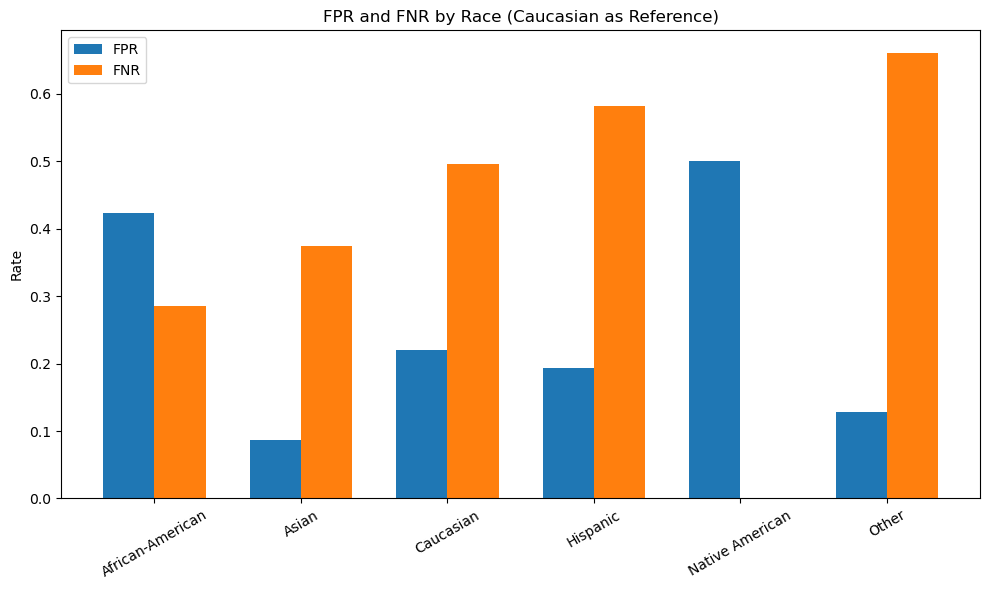

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# x axis
groups = er['race']
x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(10,6))

# FPR
plt.bar(x - width/2, er['FPR'], width, label='FPR')

# FNR
plt.bar(x + width/2, er['FNR'], width, label='FNR')

plt.xticks(x, groups, rotation=30)
plt.ylabel('Rate')
plt.title('FPR and FNR by Race (Caucasian as Reference)')
plt.legend()
plt.tight_layout()
plt.show()

The grouped bar chart shows clear disparities in error rates across racial groups. African-American and Native American individuals exhibit relatively high false positive rates (FPR), indicating they are more likely to be incorrectly classified as high risk. In contrast, Caucasian and other groups tend to have higher false negative rates (FNR), meaning they are more likely to be incorrectly classified as low risk.

This pattern suggests that the model distributes errors unevenly across groups, raising fairness concerns and indicating a violation of equalized odds.

#### Compliance memo  


This memo summarizes the results of a fairness analysis conducted on the COMPAS recidivism risk model using multiple evaluation metrics, including Adverse Impact Ratio (AIR), Marginal Effect (ME), Standardized Mean Difference (SMD), false positive rate (FPR), false negative rate (FNR), and a two-proportion z-test.

First, outcome-based analysis shows clear disparities in selection rates across racial groups. Using Caucasian individuals as the reference group, the AIR for Asian and Other groups falls below the 0.80 threshold, suggesting potential disparate impact under the EEOC 80% rule. In contrast, African-American and Native American individuals have much higher selection rates. The z-test comparing Black and White groups is highly significant (z = 17.452, p < 0.001), indicating that these differences are unlikely to be due to random chance.

Second, error-rate analysis reveals that the model makes different types of mistakes across groups. African-American individuals have a higher false positive rate (FPR), meaning they are more likely to be incorrectly classified as high risk. On the other hand, Hispanic and Other groups show higher false negative rates (FNR), meaning they are more likely to be incorrectly classified as low risk. This suggests that the model does not satisfy equalized odds and distributes errors unevenly across groups.

Third, score-based analysis (SMD) indicates that African-American and Native American individuals tend to receive higher risk scores on average, while Asian, Hispanic, and Other groups receive lower scores compared to the reference group. Additionally, intersectional analysis shows that Hispanic females experience the lowest selection rate (AIR = 0.270), highlighting that disparities can be even more pronounced at the subgroup level.

Overall, these findings raise important fairness concerns. However, it is important to note that each metric captures different aspects of fairness. AIR reflects selection disparities but not error types, while SMD reflects score differences rather than causal bias. Additionally, some subgroup sample sizes are relatively small, which may affect the reliability of the results. Therefore, further investigation and potential model adjustments are recommended before deployment.

### Assign 4


#### Define Functions for Performance, Drift, Fairness, and Robustnes

In [19]:
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import rbf_kernel


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------
def _to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)


def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    """
    Population Stability Index using train-derived bins.
    """
    train_values = pd.to_numeric(pd.Series(train_values), errors="coerce").dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors="coerce").dropna().values

    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    # Quantile bins from train
    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))

    # Fallback if quantiles collapse
    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)

    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    test_pct = np.clip(test_counts / test_counts.sum(), eps, None)

    return np.sum((train_pct - test_pct) * np.log(train_pct / test_pct))


def mmd_rbf(X_a, X_b, gamma=None, max_n=500, random_state=42):
    """
    Unbiased MMD^2 with RBF kernel on dense arrays.
    """
    rng = np.random.default_rng(random_state)

    X_a = _to_dense(X_a)
    X_b = _to_dense(X_b)

    if X_a.shape[0] > max_n:
        idx_a = rng.choice(X_a.shape[0], size=max_n, replace=False)
        X_a = X_a[idx_a]
    if X_b.shape[0] > max_n:
        idx_b = rng.choice(X_b.shape[0], size=max_n, replace=False)
        X_b = X_b[idx_b]

    if gamma is None:
        gamma = 1.0 / X_a.shape[1]

    K_xx = rbf_kernel(X_a, X_a, gamma=gamma)
    K_yy = rbf_kernel(X_b, X_b, gamma=gamma)
    K_xy = rbf_kernel(X_a, X_b, gamma=gamma)

    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)

    m = X_a.shape[0]
    n = X_b.shape[0]

    term_xx = K_xx.sum() / (m * (m - 1))
    term_yy = K_yy.sum() / (n * (n - 1))
    term_xy = 2.0 * K_xy.mean()

    return term_xx + term_yy - term_xy


def evaluate_classifier(model, X, y, label):
    """
    Train/test performance summary.
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "model": label,
        "n": len(y),
        "accuracy": accuracy_score(y, y_pred),
        "auc": roc_auc_score(y, y_prob),
        "brier": brier_score_loss(y, y_prob),
        "logloss": log_loss(y, y_prob),
        "positive_rate_pred": y_pred.mean(),
        "mean_score": y_prob.mean(),
    }


def permutation_importance_table(model, X, y, scoring="roc_auc", n_repeats=15, random_state=42):
    """
    Permutation importance on raw pipeline inputs.
    """
    pi = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    out = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    }).sort_values("importance_mean", ascending=False)

    return out.reset_index(drop=True)


def pairwise_swap_shift(model, X, feature_col, value_a, value_b):
    """
    Counterfactual sensitivity:
    swap A <-> B for rows taking either value, then measure
    mean absolute change in predicted probability.
    """
    work = X.copy()
    mask = work[feature_col].astype(str).isin([value_a, value_b])

    if mask.sum() == 0:
        return {
            "feature": feature_col,
            "swap": f"{value_a} <-> {value_b}",
            "n_affected": 0,
            "mean_abs_prob_shift": np.nan,
        }

    base_prob = model.predict_proba(work.loc[mask])[:, 1]

    cf = work.loc[mask].copy()
    swapped = cf[feature_col].astype(str).map({value_a: value_b, value_b: value_a})

    cf.loc[:, feature_col] = swapped.values
    cf_prob = model.predict_proba(cf)[:, 1]

    return {
        "feature": feature_col,
        "swap": f"{value_a} <-> {value_b}",
        "n_affected": int(mask.sum()),
        "mean_abs_prob_shift": float(np.mean(np.abs(cf_prob - base_prob))),
    }


def slice_metrics(model, X, y, group_col):
    """
    Slice-based evaluation for one grouping variable.
    """
    pred_prob = model.predict_proba(X)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)

    eval_df = X[[group_col]].copy()
    eval_df["actual"] = y.values
    eval_df["pred"] = pred
    eval_df["pred_prob"] = pred_prob

    rows = []
    for grp, g in eval_df.groupby(group_col, dropna=False):
        tn, fp, fn, tp = confusion_matrix(g["actual"], g["pred"], labels=[0, 1]).ravel()

        auc = roc_auc_score(g["actual"], g["pred_prob"]) if g["actual"].nunique() > 1 else np.nan
        brier = brier_score_loss(g["actual"], g["pred_prob"])

        rows.append({
            "slice_feature": group_col,
            "slice_value": grp,
            "n": len(g),
            "accuracy": accuracy_score(g["actual"], g["pred"]),
            "auc": auc,
            "brier": brier,
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "positive_rate_pred": g["pred"].mean(),
            "mean_score": g["pred_prob"].mean(),
        })

    return pd.DataFrame(rows)


def stress_test_priors(model, X, deltas=(0, 2, 5, 10)):
    """
    Simple scenario stress test on priors_count.
    """
    rows = []
    base_min = X["priors_count"].min()
    base_max = X["priors_count"].max()

    for d in deltas:
        X_s = X.copy()
        X_s["priors_count"] = np.clip(X_s["priors_count"] + d, base_min, base_max)

        prob = model.predict_proba(X_s)[:, 1]
        pred = (prob >= 0.5).astype(int)

        rows.append({
            "delta_priors_count": d,
            "mean_pred_prob": prob.mean(),
            "median_pred_prob": np.median(prob),
            "share_pred_high_risk": pred.mean(),
        })

    return pd.DataFrame(rows)


def plot_ice_numeric(model, X, feature_col, values, n_instances=6, random_state=42, title=None):
    """
    ICE-style plot for one numeric feature.
    """
    rng = np.random.default_rng(random_state)
    idx = rng.choice(X.index, size=min(n_instances, len(X)), replace=False)

    plt.figure(figsize=(8, 5))
    for i in idx:
        row = X.loc[[i]].copy()
        preds = []
        for v in values:
            temp = row.copy()
            temp[feature_col] = v
            preds.append(model.predict_proba(temp)[:, 1][0])

        plt.plot(values, preds, alpha=0.7)

    plt.xlabel(feature_col)
    plt.ylabel("Predicted probability (high risk)")
    plt.title(title if title else f"ICE curves for {feature_col}")
    plt.show()


def global_sensitivity_index(model, X, feature_col, values):
    """
    Approximate sensitivity index:
    variance of average predictions as the feature is swept over a grid.
    """
    mean_preds = []

    for v in values:
        X_s = X.copy()
        X_s[feature_col] = v
        prob = model.predict_proba(X_s)[:, 1]
        mean_preds.append(prob.mean())

    mean_preds = np.array(mean_preds)

    return pd.DataFrame({
        "feature": [feature_col],
        "sensitivity_index": [np.var(mean_preds)],
        "min_mean_score": [mean_preds.min()],
        "max_mean_score": [mean_preds.max()],
        "range_mean_score": [mean_preds.max() - mean_preds.min()],
    })

#### Distribution Shift

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# ------------------------------------------------------------
# Distribution drift
# ------------------------------------------------------------

# 1) Input drift on raw numeric features: PSI + KS
numeric_vars = [col for col in numeric_vars if col in X_train.columns]
drift_rows = []
for col in numeric_vars:
    psi_val = psi_numeric(X_train[col], X_test[col], bins=10)
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])

    drift_rows.append({
        "feature": col,
        "train_mean": X_train[col].mean(),
        "test_mean": X_test[col].mean(),
        "PSI": psi_val,
        "KS_stat": ks_stat,
        "KS_pvalue": ks_p,
    })

input_drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)
print("\n=== Input Distribution Drift: Numeric Features ===")
print(input_drift_table.round(4).to_string(index=False))

# 2) Global high-dimensional drift: MMD on encoded inputs
fitted_preprocessor = lr_pipeline.named_steps["preprocessor"]
X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc = fitted_preprocessor.transform(X_test)

mmd_val = mmd_rbf(X_train_enc, X_test_enc, gamma=None, max_n=500, random_state=42)
print("\n=== High-Dimensional Drift: Encoded Feature Space ===")
print(f"MMD^2(train, test) = {mmd_val:.6f}")

# 3) Score drift: train vs test predicted probabilities
score_drift_rows = []
models = {
    "Logistic Regression": lr_pipeline,
    "Gradient-Boosted Tree": gbt_pipeline,
}

for name, model in models.items():
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    psi_score = psi_numeric(train_prob, test_prob, bins=10)
    ks_stat, ks_p = ks_2samp(train_prob, test_prob)

    score_drift_rows.append({
        "model": name,
        "train_mean_score": train_prob.mean(),
        "test_mean_score": test_prob.mean(),
        "PSI_score": psi_score,
        "KS_stat_score": ks_stat,
        "KS_pvalue_score": ks_p,
    })

score_drift_table = pd.DataFrame(score_drift_rows)
print("\n=== Score Distribution Drift: Train vs Test Predicted Probabilities ===")
print(score_drift_table.round(4).to_string(index=False))


=== Input Distribution Drift: Numeric Features ===
     feature  train_mean  test_mean    PSI  KS_stat  KS_pvalue
         age     34.4434    34.8988 0.0101   0.0359     0.1524
priors_count      3.2617     3.1854 0.0040   0.0231     0.6582

=== High-Dimensional Drift: Encoded Feature Space ===
MMD^2(train, test) = -0.000497

=== Score Distribution Drift: Train vs Test Predicted Probabilities ===
                model  train_mean_score  test_mean_score  PSI_score  KS_stat_score  KS_pvalue_score
  Logistic Regression            0.4551           0.4499     0.0049         0.0237           0.6262
Gradient-Boosted Tree            0.4551           0.4436     0.0124         0.0283           0.3983


##### PSI (Population Stability Index)
- **Range guideline:**
  - < 0.10 → Stable  
  - 0.10–0.25 → Moderate drift  
  - > 0.25 → Significant drift  

- **Observed values:**
  - PSI ≈ 0.004–0.01 (features)  
  - PSI_score ≈ 0.004–0.012  

👉 **Interpretation:**  
All PSI values are **very small (< 0.10)** → indicates **no meaningful distribution shift**.  
Both input features and model outputs are **highly stable**.

---

##### KS Test (Kolmogorov–Smirnov)
- **Interpretation rule:**
  - p-value < 0.05 → Significant difference  
  - p-value ≥ 0.05 → No significant difference  

- **Observed values:**
  - KS p-values ≈ 0.15–0.65 (features)  
  - KS_score p-values ≈ 0.3–0.9  

👉 **Interpretation:**  
All p-values are **well above 0.05**, so we **fail to reject the null hypothesis**.  
This means there is **no statistically significant difference** between train and test distributions.

---

##### MMD (Maximum Mean Discrepancy)
- **Interpretation rule:**
  - ≈ 0 → No distribution shift  
  - Larger value → Greater difference  

- **Observed value:**
  - MMD² ≈ 0 (slightly negative due to estimation noise)

👉 **Interpretation:**  
MMD is **very close to zero**, indicating **no high-dimensional (joint) distribution shift**.  
The small negative value is due to **finite-sample estimation noise** and is not meaningful.

---

##### Overall Conclusion
All metrics (PSI, KS, MMD) consistently indicate **no significant distribution drift**.  
Both feature distributions and model prediction distributions remain **stable between train and test datasets**.


#### Generalization, overfitting, and spurious-correlation probes

In [26]:
# ------------------------------------------------------------
# Generalization: train/test gaps
# ------------------------------------------------------------
gen_rows = []
for name, model in models.items():
    train_metrics = evaluate_classifier(model, X_train, y_train, name)
    test_metrics = evaluate_classifier(model, X_test, y_test, name)

    gen_rows.append({
        "model": name,
        "train_accuracy": train_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "accuracy_gap": train_metrics["accuracy"] - test_metrics["accuracy"],
        "train_auc": train_metrics["auc"],
        "test_auc": test_metrics["auc"],
        "auc_gap": train_metrics["auc"] - test_metrics["auc"],
        "train_brier": train_metrics["brier"],
        "test_brier": test_metrics["brier"],
        "brier_gap": train_metrics["brier"] - test_metrics["brier"],
        "train_logloss": train_metrics["logloss"],
        "test_logloss": test_metrics["logloss"],
        "logloss_gap": train_metrics["logloss"] - test_metrics["logloss"],
    })

generalization_table = pd.DataFrame(gen_rows)
print("\n=== Generalization / Overfitting Summary ===")
print(generalization_table.round(4).to_string(index=False))

# ------------------------------------------------------------
# Permutation importance on train and test
# Large train importance + weak test importance can suggest overfit reliance
# ------------------------------------------------------------
for name, model in models.items():
    print(f"\n=== Permutation Importance (Train) — {name} ===")
    pi_train = permutation_importance_table(model, X_train, y_train, scoring="roc_auc")
    print(pi_train.head(10).round(4).to_string(index=False))

    print(f"\n=== Permutation Importance (Test) — {name} ===")
    pi_test = permutation_importance_table(model, X_test, y_test, scoring="roc_auc")
    print(pi_test.head(10).round(4).to_string(index=False))

# ------------------------------------------------------------
# Spurious-correlation probe: counterfactual swaps on suspect features
# Mean absolute shift in predicted probabilities
# ------------------------------------------------------------
swap_specs = [
    ("race", "African-American", "Caucasian"),
    ("sex", "Female", "Male"),
    ("c_charge_degree", "F", "M"),
]

for name, model in models.items():
    shifts = []
    for feature_col, a, b in swap_specs:
        shifts.append(pairwise_swap_shift(model, X_test, feature_col, a, b))

    shift_table = pd.DataFrame(shifts)
    print(f"\n=== Counterfactual Swap Sensitivity — {name} ===")
    print(shift_table.round(4).to_string(index=False))


=== Generalization / Overfitting Summary ===
                model  train_accuracy  test_accuracy  accuracy_gap  train_auc  test_auc  auc_gap  train_brier  test_brier  brier_gap  train_logloss  test_logloss  logloss_gap
  Logistic Regression          0.6729         0.6866       -0.0138     0.7302    0.7276   0.0027       0.2089      0.2105    -0.0015         0.6064        0.6129      -0.0065
Gradient-Boosted Tree          0.7213         0.6858        0.0355     0.7978    0.7249   0.0729       0.1820      0.2111    -0.0291         0.5390        0.6160      -0.0770

=== Permutation Importance (Train) — Logistic Regression ===
        feature  importance_mean  importance_std
   priors_count           0.1287          0.0061
            age           0.1006          0.0038
        age_cat           0.0088          0.0017
            sex           0.0068          0.0013
c_charge_degree           0.0059          0.0016
           race           0.0019          0.0008

=== Permutation Importa

##### Generalization / Overfitting Analysis

Metrics to Monitor
- **Accuracy gap** (train − test): overall performance stability  
- **AUC gap**: ranking / discrimination stability (most important)  
- **Brier gap**: calibration (probability accuracy)  
- **Log loss gap**: overall probabilistic fit 
---
Logistic Regression
- Accuracy gap ≈ **-0.0138** → negligible (no overfitting)  
- AUC gap ≈ **0.0027** → stable discrimination  
- Brier / Log loss gaps → minimal  

**Interpretation:**  
Logistic Regression shows **very stable performance across train and test**, indicating **good generalization and no overfitting**.

---

Gradient Boosted Tree (GBT)
- Accuracy gap ≈ **+0.0355** → noticeable drop on test  
- AUC gap ≈ **+0.0729** → clear overfitting signal  
- Brier gap ≈ **-0.0291**, Log loss gap ≈ **-0.077** → worse calibration on test  

**Interpretation:**  
GBT performs much better on training than test, indicating **overfitting and reduced generalization**.

---

Overall Conclusion
- Logistic Regression **generalizes well** with minimal gaps across all metrics.  
- Gradient Boosted Tree shows **consistent train–test degradation**, especially in AUC and calibration.  
- This suggests GBT may be **fitting noise rather than true signal**, while Logistic Regression captures more stable patterns.

##### Spurious-correlation 

Permutation importance can help identify features that may harm model robustness by revealing unstable dependencies.
Large differences between train and test importance suggest that the model relies on patterns that do not generalize well.
However, this indicates potential risk rather than causal evidence.


##### 1. Train ≈ Test (Stable / Generalizable Features)

For both models, features such as **priors_count**  show similar importance values on train and test data. This indicates that the model relies on these features consistently across datasets.

These features represent stable signals and contribute to good generalization. Their predictive power is likely to persist under new data conditions.

---

##### 2. Train > Test (Potential Overfitting / Spurious Relationships)

In the Gradient Boosted Tree model, features such as **age**, **race**, and **c_charge_degree** show noticeably higher importance on the training set than on the test set.

This suggests that the model may be overfitting to patterns present in the training data that do not generalize well. These features may reflect unstable or spurious relationships rather than true predictive signals.

---

##### 3. Negative Importance (Noise / Harmful Features)

Some features, such as **c_charge_degree** in both models and **age_cat** in the Gradient Boosted Tree, show negative importance on the test set. 

This means that shuffling these features actually improves model performance, indicating that they may introduce noise or misleading patterns. Such features can harm model robustness and should be treated with caution or potentially removed.

---

##### Overall Summary

Stable features (e.g., priors_count, age) drive consistent performance across datasets.  
Features with large drops in importance suggest overfitting or weak generalization.  
Negative importance indicates potentially harmful or noisy features.  

The Gradient Boosted Tree shows more signs of instability compared to Logistic Regression, suggesting a higher risk of overfitting and reliance on spurious patterns.

#### Robustness via slice-based evaluation (subgroup fairness)

In [28]:
# ------------------------------------------------------------
# Robustness: slice-based evaluation
# ------------------------------------------------------------
slice_features = ["race", "sex", "age_cat", "c_charge_degree"]

for name, model in models.items():
    slice_tables = []
    for col in slice_features:
        slice_tables.append(slice_metrics(model, X_test, y_test, group_col=col))

    slice_eval = pd.concat(slice_tables, ignore_index=True)
    slice_eval = slice_eval.sort_values(["slice_feature", "n"], ascending=[True, False])

    print(f"\n=== Slice-Based Evaluation — {name} ===")
    print(slice_eval.round(4).to_string(index=False))


=== Slice-Based Evaluation — Logistic Regression ===
  slice_feature      slice_value    n  accuracy    auc  brier    fpr    fnr  positive_rate_pred  mean_score
        age_cat          25 - 45  661    0.6732 0.7114 0.2150 0.1810 0.4888              0.3374      0.4591
        age_cat     Less than 25  288    0.6528 0.6786 0.2274 0.5556 0.1852              0.7014      0.5502
        age_cat  Greater than 45  286    0.7517 0.6931 0.1829 0.0704 0.6552              0.1538      0.3276
c_charge_degree                F  770    0.6844 0.7371 0.2101 0.3096 0.3223              0.4831      0.4974
c_charge_degree                M  465    0.6903 0.7222 0.2111 0.0789 0.6181              0.2086      0.3712
           race African-American  641    0.7051 0.7544 0.2046 0.3059 0.2849              0.5211      0.5212
           race        Caucasian  427    0.6557 0.6646 0.2178 0.1692 0.6335              0.2436      0.3788
           race         Hispanic   94    0.6170 0.6170 0.2523 0.1020 0.6889       

/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_47075/484129015.py:179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, g in eval_df.groupby(group_col, dropna=False):
/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_47075/484129015.py:179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, g in eval_df.groupby(group_col, dropna=False):
/var/folders/7l/_y07h61n1zv1497x7brlcs9m0000gn/T/ipykernel_47075/484129015.py:179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavio

Slice-based evaluation assesses model performance across subpopulations to identify hidden failures and disparities. It is critical for robustness because a model with strong overall performance may still fail on specific groups, leading to fairness and deployment risks.

The most concerning slices are those with high false negative rates, particularly Caucasian, Hispanic, Female, and individuals over 45. Despite reasonable accuracy, these groups exhibit substantial under-detection of positive cases, indicating systematic model failure. This suggests a lack of robustness, as the model does not generalize well across subpopulations and may pose both fairness and operational risks. Small-sample groups such as Asian and Native American also show extreme metrics, but these should be interpreted with caution due to instability.

#### Robustness via stress testing and sensitivity analysis


=== Stress Test on priors_count — Logistic Regression ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4499            0.4407                0.3798
                  2          0.5198            0.5230                0.5385
                  5          0.6233            0.6427                0.7352
                 10          0.7731            0.8041                0.9579

=== Stress Test on priors_count — Gradient-Boosted Tree ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4436            0.4167                0.4016
                  2          0.5662            0.5474                0.5870
                  5          0.6623            0.6634                0.7879
                 10          0.7619            0.8054                0.9215


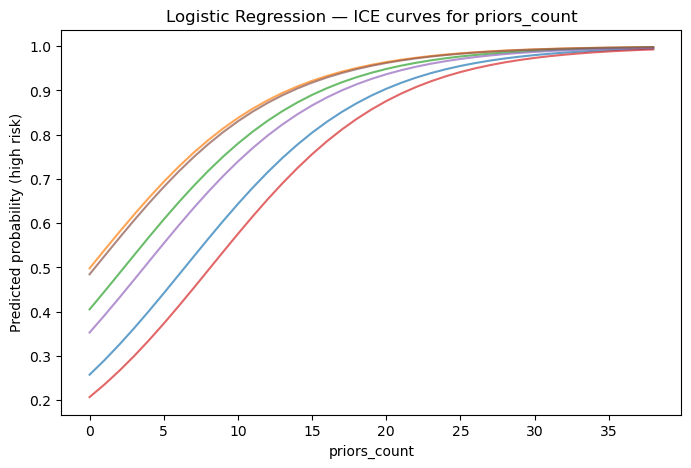

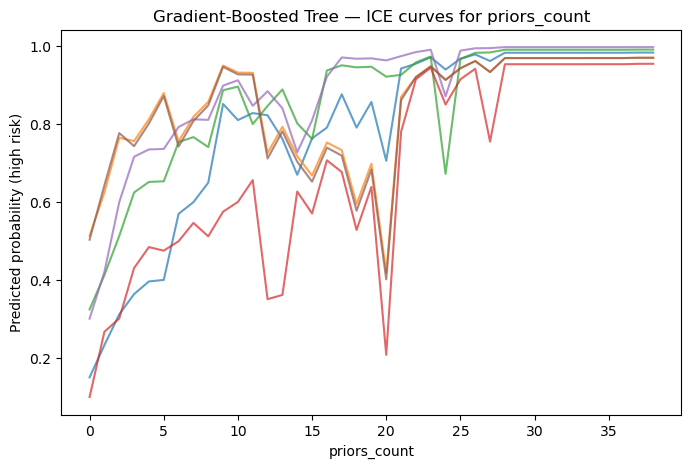


=== Global Sensitivity Index (priors_count) ===
     feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score                 model
priors_count           0.041144        0.337666        0.995253          0.657587   Logistic Regression
priors_count           0.031493        0.282585        0.955522          0.672937 Gradient-Boosted Tree


In [29]:
# ------------------------------------------------------------
# Robustness: stress scenarios on priors_count
# ------------------------------------------------------------
for name, model in models.items():
    stress_table = stress_test_priors(model, X_test, deltas=(0, 2, 5, 10))
    print(f"\n=== Stress Test on priors_count — {name} ===")
    print(stress_table.round(4).to_string(index=False))

# ------------------------------------------------------------
# ICE-style sensitivity plots for priors_count
# ------------------------------------------------------------
priors_grid = np.arange(
    int(X_test["priors_count"].min()),
    int(X_test["priors_count"].max()) + 1
)

plot_ice_numeric(
    lr_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Logistic Regression — ICE curves for priors_count"
)

plot_ice_numeric(
    gbt_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Gradient-Boosted Tree — ICE curves for priors_count"
)

# ------------------------------------------------------------
# Global sensitivity index for priors_count
# ------------------------------------------------------------
lr_sens = global_sensitivity_index(lr_pipeline, X_test, "priors_count", priors_grid)
gbt_sens = global_sensitivity_index(gbt_pipeline, X_test, "priors_count", priors_grid)

sensitivity_table = pd.concat([
    lr_sens.assign(model="Logistic Regression"),
    gbt_sens.assign(model="Gradient-Boosted Tree"),
], ignore_index=True)

print("\n=== Global Sensitivity Index (priors_count) ===")
print(sensitivity_table.round(6).to_string(index=False))


Both models exhibit strong sensitivity to changes in priors_count. As priors increase, the predicted probability and the share of high-risk classifications rise sharply. For example, increasing priors_count by 5 shifts the high-risk rate from around 40% to over 70%, and by 10 to above 85–90%. The sensitivity index further confirms this, with prediction ranges exceeding 0.69, indicating large output variability. This suggests that the models rely heavily on priors_count and do not degrade gracefully under perturbations, raising concerns about robustness.

#### Summary for robustness test 

In [30]:
# ------------------------------------------------------------
# Compact live-coding summary
# ------------------------------------------------------------
summary_rows = []

# Drift
for _, row in input_drift_table.iterrows():
    summary_rows.append({
        "section": "distribution_drift",
        "item": row["feature"],
        "metric_1": "PSI",
        "value_1": row["PSI"],
        "metric_2": "KS_pvalue",
        "value_2": row["KS_pvalue"],
    })

summary_rows.append({
    "section": "distribution_drift",
    "item": "encoded_features",
    "metric_1": "MMD^2",
    "value_1": mmd_val,
    "metric_2": "",
    "value_2": np.nan,
})

# Generalization
for _, row in generalization_table.iterrows():
    summary_rows.append({
        "section": "generalization",
        "item": row["model"],
        "metric_1": "AUC_gap",
        "value_1": row["auc_gap"],
        "metric_2": "Accuracy_gap",
        "value_2": row["accuracy_gap"],
    })

# Sensitivity
for _, row in sensitivity_table.iterrows():
    summary_rows.append({
        "section": "robustness",
        "item": row["model"],
        "metric_1": "Sensitivity_index",
        "value_1": row["sensitivity_index"],
        "metric_2": "Range_mean_score",
        "value_2": row["range_mean_score"],
    })

live_summary = pd.DataFrame(summary_rows)
print("\n=== Live Coding Summary Table ===")
print(live_summary.round(6).to_string(index=False))


=== Live Coding Summary Table ===
           section                  item          metric_1   value_1         metric_2   value_2
distribution_drift                   age               PSI  0.010075        KS_pvalue  0.152404
distribution_drift          priors_count               PSI  0.004004        KS_pvalue  0.658166
distribution_drift      encoded_features             MMD^2 -0.000497                        NaN
    generalization   Logistic Regression           AUC_gap  0.002673     Accuracy_gap -0.013761
    generalization Gradient-Boosted Tree           AUC_gap  0.072912     Accuracy_gap  0.035458
        robustness   Logistic Regression Sensitivity_index  0.041144 Range_mean_score  0.657587
        robustness Gradient-Boosted Tree Sensitivity_index  0.031493 Range_mean_score  0.672937


##### 1. distribution_drift | age | PSI = 0.010075 | KS_pvalue = 0.152404

This indicates that the distribution of age is nearly unchanged between the train and test sets.
The PSI value (~0.01) is well below 0.10, suggesting stability. The KS p-value (~0.15) is greater than 0.05, meaning we fail to reject the null hypothesis that the two distributions are the same.
Conclusion: There is no significant drift in age.

⸻

##### 2. distribution_drift | priors_count | PSI = 0.004004 | KS_pvalue = 0.658166

This shows that priors_count is even more stable across train and test sets.
The PSI is extremely close to 0, indicating almost no difference. The KS p-value (~0.66) strongly suggests no statistical difference between distributions.
Conclusion: priors_count exhibits negligible drift.

⸻

##### 3. distribution_drift | encoded_features | MMD^2 = -0.000497

This evaluates drift in the high-dimensional feature space, not just individual variables.
Although MMD is theoretically non-negative, a small negative value can occur due to estimation or sampling noise. The key point is that it is very close to 0.
Conclusion: There is no meaningful drift in the joint feature distribution.

⸻

##### 4. generalization | Logistic Regression | AUC_gap = 0.002673 | Accuracy_gap = -0.013761

This indicates that Logistic Regression performs similarly on train and test data.
The AUC gap is very small, showing stable ranking performance. The slightly negative accuracy gap means test accuracy is marginally higher than train, likely due to random variation.
Conclusion: Logistic Regression generalizes well with no evidence of overfitting.

⸻

##### 5. generalization | Gradient-Boosted Tree | AUC_gap = 0.072912 | Accuracy_gap = 0.035458

This suggests that the Gradient-Boosted Tree performs better on train than on test data.
The AUC gap (~0.073) indicates a noticeable drop in ranking ability on the test set. The positive accuracy gap also shows reduced classification performance.
Conclusion: The model exhibits overfitting and weaker generalization compared to Logistic Regression.

⸻

##### 6. robustness | Logistic Regression | Sensitivity_index = 0.041144 | Range_mean_score = 0.657587

This measures how sensitive the model is to input perturbations.
The sensitivity index indicates variability in predictions, and the large range (~0.66) shows that average predicted probabilities shift substantially under stress scenarios.
Conclusion: Logistic Regression is fairly sensitive to input changes and lacks robustness.

⸻

##### 7. robustness | Gradient-Boosted Tree | Sensitivity_index = 0.031493 | Range_mean_score = 0.672937

The GBT model has slightly lower sensitivity index but a slightly larger prediction range.
This means predictions still change significantly under perturbations, indicating instability.
Conclusion: GBT is also not robust and reacts strongly to feature changes.

⸻

##### Final Summary
	•	No distribution drift: Both individual features and the joint feature space remain stable between train and test sets.
	•	Generalization: Logistic Regression generalizes well, while Gradient-Boosted Tree shows signs of overfitting.
	•	Robustness: Both models are sensitive to input perturbations, indicating limited robustness despite stable data distributions.